In [1]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [3]:
!pip install codecarbon --quiet

### LinearSVR

In [4]:
# ============================================================
# FLEXMark - LinearSVR Baseline (Proper Embedding, Non-blind verify)
# Cell 1: imports + utilities  (UPDATED: LPIPS + stronger attacks + detection metrics)
# ============================================================

import os, json, time, random
from glob import glob
from dataclasses import dataclass
from io import BytesIO
import hashlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import joblib
from sklearn.svm import LinearSVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler

# CO2
try:
    from codecarbon import EmissionsTracker
except Exception:
    EmissionsTracker = None

# SSIM
try:
    from skimage.metrics import structural_similarity as sk_ssim
except Exception:
    sk_ssim = None

# ROC/AUC
try:
    from sklearn.metrics import roc_curve, auc
except Exception:
    roc_curve, auc = None, None

# LPIPS
try:
    import torch
    import lpips
    _lpips_model = lpips.LPIPS(net="alex")  # common baseline
    _lpips_model.eval()
    if torch.cuda.is_available():
        _lpips_model = _lpips_model.cuda()
except Exception:
    torch, lpips, _lpips_model = None, None, None


def lpips_np(a, b):
    """
    LPIPS expects [-1,1] tensors, shape [1,3,H,W]
    Lower is better (more perceptually similar).
    """
    if _lpips_model is None or torch is None:
        return float("nan")
    a = np.asarray(a, np.float32)
    b = np.asarray(b, np.float32)
    ta = torch.from_numpy(a).permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0
    tb = torch.from_numpy(b).permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0
    if next(_lpips_model.parameters()).is_cuda:
        ta = ta.cuda()
        tb = tb.cuda()
    with torch.no_grad():
        d = _lpips_model(ta, tb).item()
    return float(d)


def detection_metrics_from_scores(labels, scores):
    if roc_curve is None or auc is None:
        return {
            "auc": float("nan"),
            "eer": float("nan"),
            "best_acc": float("nan"),
            "thr_eer": float("nan"),
            "far_eer": float("nan"),
            "frr_eer": float("nan"),
            "thr_best_acc": float("nan"),
        }

    fpr, tpr, thr = roc_curve(labels, scores)
    roc_auc = float(auc(fpr, tpr))

    fnr = 1.0 - tpr
    idx = int(np.nanargmin(np.abs(fpr - fnr)))  # closest point to EER
    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    thr_eer = float(thr[idx])
    far_eer = float(fpr[idx])
    frr_eer = float(fnr[idx])

    labels_np = np.asarray(labels).astype(np.int32)
    scores_np = np.asarray(scores).astype(np.float32)

    best_acc = -1.0
    best_thr = thr_eer
    for t in thr:
        pred = (scores_np >= t).astype(np.int32)
        acc_ = float(np.mean(pred == labels_np))
        if acc_ > best_acc:
            best_acc = acc_
            best_thr = float(t)

    return {
        "auc": roc_auc,
        "eer": eer,
        "best_acc": float(best_acc),
        "thr_eer": thr_eer,
        "far_eer": far_eer,
        "frr_eer": frr_eer,
        "thr_best_acc": best_thr,
    }


# ---------------------------
# Repro / IO
# ---------------------------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)


def ensure_dir(p):
    os.makedirs(p, exist_ok=True)


def save_json(obj, path):
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, indent=2)


def read_rgb(path, hw):
    img = Image.open(path).convert("RGB").resize((hw, hw), Image.BICUBIC)
    return np.asarray(img).astype(np.float32) / 255.0


def np_to_pil(x):
    x = np.clip(x * 255.0, 0, 255).astype(np.uint8)
    return Image.fromarray(x)


def pil_to_np(p):
    return np.asarray(p).astype(np.float32) / 255.0


# ---------------------------
# Metrics
# ---------------------------
def mse(a, b):
    a = np.asarray(a, np.float32)
    b = np.asarray(b, np.float32)
    return float(np.mean((a - b) ** 2))


def psnr_from_mse(m):
    if m <= 1e-12:
        return 99.0
    return float(10.0 * np.log10(1.0 / m))


def psnr(a, b):
    return psnr_from_mse(mse(a, b))


def ssim_np(a, b):
    if sk_ssim is None:
        return float("nan")
    return float(sk_ssim(a, b, channel_axis=2, data_range=1.0))


def binarize01(x, thr=0.5):
    return (x >= thr).astype(np.float32)


def nc(a, b):
    a = a.astype(np.float32).flatten()
    b = b.astype(np.float32).flatten()
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-8
    return float(np.dot(a, b) / denom)


def ber(a_bin, b_bin):
    a_bin = a_bin.astype(np.float32).flatten()
    b_bin = b_bin.astype(np.float32).flatten()
    return float(np.mean(a_bin != b_bin) * 100.0)


# ---------------------------
# Payload
# 128 bits -> 8x16 grid; 256 bits -> 16x16 grid
# ---------------------------
def sample_bits(B):
    if B not in (128, 256):
        raise ValueError("Supported B: 128 or 256")
    return np.random.randint(0, 2, size=(B,), dtype=np.int32)

def mark_to_bits(mark_rgb, B):
    """
    Deterministically derive B bits from the dataset mark image.
    Uses SHA-256 in counter mode so it works for both 128 and 256 bits.
    """
    if B not in (128, 256):
        raise ValueError("Supported B: 128 or 256")

    # Convert mark to bytes (stable)
    m = (np.clip(mark_rgb, 0, 1) * 255.0).astype(np.uint8)
    base = m.tobytes()

    # Need B bits => B/8 bytes
    need_bytes = B // 8
    out = bytearray()
    ctr = 0
    while len(out) < need_bytes:
        h = hashlib.sha256(base + ctr.to_bytes(4, "little")).digest()
        out.extend(h)
        ctr += 1
    out = bytes(out[:need_bytes])

    # bytes -> bits (0/1)
    bits = np.unpackbits(np.frombuffer(out, dtype=np.uint8)).astype(np.int32)
    return bits[:B]


def build_payload_from_mark(mark_path, hw, B):
    """
    Read dataset mark PNG, derive B bits, convert to grid, upsample to HW RGB.
    Returns:
      W_rgb (H,W,3) in [0,1] used for embedding
      W_true (gh,gw,1) in [0,1] for evaluation
      meta = (gh, gw)
    """
    mark_rgb = read_rgb(mark_path, hw)  # uses your existing read_rgb
    bits = mark_to_bits(mark_rgb, B)
    grid, (gh, gw) = bits_to_grid(bits, B)
    W_true = grid[..., None].astype(np.float32)
    W_rgb = upsample_grid_to_hw_rgb(grid, hw)
    return W_rgb, W_true, (gh, gw)


def bits_to_grid(bits, B):
    if B == 128:
        return bits.reshape(8, 16).astype(np.float32), (8, 16)
    if B == 256:
        return bits.reshape(16, 16).astype(np.float32), (16, 16)
    raise ValueError("B must be 128 or 256")


def upsample_grid_to_hw_rgb(grid01, hw):
    pil = Image.fromarray((grid01 * 255).astype(np.uint8)).resize((hw, hw), Image.NEAREST)
    arr = np.asarray(pil).astype(np.float32) / 255.0
    return np.repeat(arr[..., None], 3, axis=2)


# ---------------------------
# Non-blind extraction (verifier has cover C)
# Y = clip(C + r, 0,1), where r in [-eps, +eps]
# Then r/eps ∈ [-1,1] -> map to [0,1] -> downsample -> bits/grid
# ---------------------------
def inverse_residual_decode(Y, C, eps):
    r = np.clip(Y - C, -eps, eps)
    w_proxy = r / (eps + 1e-8)  # [-1,1]
    return w_proxy


def decode_to_grid(w_proxy_rgb, gh, gw):
    g = np.mean((w_proxy_rgb + 1.0) / 2.0, axis=2)  # [-1,1] -> [0,1]
    pil = Image.fromarray((g * 255).astype(np.uint8)).resize((gw, gh), Image.NEAREST)
    return np.asarray(pil).astype(np.float32) / 255.0


# ---------------------------
# Attacks (reviewer-aligned)
# - JPEG sweep 10–90
# - resizing / resampling
# - crop+resize
# - gamma (photometric)
# - screenshot / recompression
# - blur + sharpen
# + (AI laundering is in later cells)
# ---------------------------
def attack_jpeg(x, quality=10):
    pil = np_to_pil(x)
    buf = BytesIO()
    pil.save(buf, format="JPEG", quality=int(quality))
    buf.seek(0)
    out = Image.open(buf).convert("RGB")
    return pil_to_np(out)


def attack_resize(x, scale=0.75):
    H, W, _ = x.shape
    nh, nw = int(H * scale), int(W * scale)
    pil = np_to_pil(x).resize((nw, nh), Image.BICUBIC).resize((W, H), Image.BICUBIC)
    return pil_to_np(pil)


def attack_crop_resize(x, crop_frac=0.10):
    H, W, _ = x.shape
    ch = int(H * (1 - crop_frac))
    cw = int(W * (1 - crop_frac))
    y0 = np.random.randint(0, H - ch + 1)
    x0 = np.random.randint(0, W - cw + 1)
    crop = x[y0 : y0 + ch, x0 : x0 + cw, :]
    pil = np_to_pil(crop).resize((W, H), Image.BICUBIC)
    return pil_to_np(pil)


def attack_gamma(x, gamma=1.2):
    x = np.clip(x, 0, 1)
    return np.clip(x ** gamma, 0, 1)


def attack_screenshot_recompress(x, q1=35, q2=70):
    y = attack_jpeg(x, q1)
    y = attack_resize(y, 0.92)
    y = attack_jpeg(y, q2)
    return y


def attack_gaussian_blur(x, radius=1.2):
    from PIL import ImageFilter

    pil = np_to_pil(x)
    out = pil.filter(ImageFilter.GaussianBlur(radius=float(radius)))
    return pil_to_np(out)


def attack_unsharp_mask(x, radius=2.0, percent=150, threshold=3):
    from PIL import ImageFilter

    pil = np_to_pil(x)
    out = pil.filter(
        ImageFilter.UnsharpMask(
            radius=float(radius),
            percent=int(percent),
            threshold=int(threshold),
        )
    )
    return pil_to_np(out)


ATTACKS = {
    "clean": lambda im: im,
    # JPEG sweep (10–90)
    "jpeg10": lambda im: attack_jpeg(im, 10),
    "jpeg30": lambda im: attack_jpeg(im, 30),
    "jpeg50": lambda im: attack_jpeg(im, 50),
    "jpeg70": lambda im: attack_jpeg(im, 70),
    "jpeg90": lambda im: attack_jpeg(im, 90),
    # geometry / resampling
    "resize075": lambda im: attack_resize(im, 0.75),
    "crop10": lambda im: attack_crop_resize(im, 0.10),
    # photometric
    "gamma12": lambda im: attack_gamma(im, 1.2),
    # screenshot
    "screenshot": lambda im: attack_screenshot_recompress(im, 35, 70),
    # blur / sharpen
    "blur": lambda im: attack_gaussian_blur(im, 1.2),
    "sharpen": lambda im: attack_unsharp_mask(im, radius=2.0, percent=150, threshold=3),
    "launder_only": lambda im: im,  # placeholder, laundering applied in Cell 4
}


# ---------------------------
# CodeCarbon
# ---------------------------
def cc_start(name, out_dir):
    if EmissionsTracker is None:
        return None
    try:
        tr = EmissionsTracker(
            project_name=name,
            output_dir=out_dir,
            measure_power_secs=1,
            log_level="error",
        )
        tr.start()
        return tr
    except Exception:
        return None


def cc_stop(tr):
    if tr is None:
        return None
    try:
        return tr.stop()
    except Exception:
        return None


In [7]:
# ============================================================
# Cell 2: config + paths 
# - uses ATTACKS (not ATTACKS_5)
# - keeps payload mode 128/256
# - adds run metadata placeholders
# ============================================================

import platform, socket
import numpy as np

PAYLOAD_MODE = "bits256"

BASE_DIR = "/kaggle/input/image-watermarking/dataset"
OUT_DIR = f"/kaggle/working/flexmark_out_linearsvr_{PAYLOAD_MODE}"
ensure_dir(OUT_DIR)

# Required sizes
TRAIN_N = 5000
TEST_N  = 1000
EVAL_N  = 1000

# Security/imperceptibility control
HW  = 128
EPS = 0.02  # residual budget (imperceptibility is measured vs cover)

SEED = 42
set_seed(SEED)

# Dataset layout
trC = sorted(glob(os.path.join(BASE_DIR, "train", "cover", "*.JPEG")))
trW = sorted(glob(os.path.join(BASE_DIR, "train", "mark",  "*.png")))
teC = sorted(glob(os.path.join(BASE_DIR, "test",  "cover", "*.JPEG")))
teW = sorted(glob(os.path.join(BASE_DIR, "test",  "mark",  "*.png")))

n_train = min(len(trC), len(trW), TRAIN_N)
n_test  = min(len(teC), len(teW), TEST_N)

trC, trW = trC[:n_train], trW[:n_train]
teC, teW = teC[:n_test],  teW[:n_test]

print("Train pairs used:", len(trC))
print("Test pairs used :", len(teC))
print("Example cover:", trC[0] if trC else "NONE")
print("Example mark :", trW[0] if trW else "NONE")

# ------------------------------------------------------------
# Run metadata (CO2)
# ------------------------------------------------------------
RUN_META = {
    "seed": int(SEED),
    "hw": int(HW),
    "eps": float(EPS),
    "payload_mode": str(PAYLOAD_MODE),
    "payload_bits": 128 if PAYLOAD_MODE == "bits128" else 256,
    "train_n_requested": int(TRAIN_N),
    "test_n_requested": int(TEST_N),
    "eval_n_requested": int(EVAL_N),
    "train_pairs_used": int(len(trC)),
    "test_pairs_used": int(len(teC)),
    "attack_names": list(ATTACKS.keys()),  # <-- from Cell 1
    # environment info for reproducibility
    "platform": platform.platform(),
    "python_version": platform.python_version(),
    "hostname": socket.gethostname(),
    "numpy_version": np.__version__,
}

save_json(RUN_META, os.path.join(OUT_DIR, "run_meta.json"))
print("Saved run metadata to:", os.path.join(OUT_DIR, "run_meta.json"))


Train pairs used: 5000
Test pairs used : 1000
Example cover: /kaggle/input/image-watermarking/dataset/train/cover/ILSVRC2012_val_00005002.JPEG
Example mark : /kaggle/input/image-watermarking/dataset/train/mark/airplane0003.png
Saved run metadata to: /kaggle/working/flexmark_out_linearsvr_bits256/run_meta.json


In [8]:
# ============================================================
# Cell 3: LinearSVR_DCT_Embedder + FAST AI laundering attacker (CNN patch denoiser)
# ============================================================

import tensorflow as tf
from tensorflow.keras import layers, Model, Input

# ---------- DCT helpers (pure numpy) ----------
def dct_1d(x):
    x = np.asarray(x, np.float32)
    N = x.shape[0]
    n = np.arange(N)
    k = n[:, None]
    M = np.cos(np.pi * (2 * n + 1) * k / (2 * N)).astype(np.float32)
    alpha = np.ones(N, np.float32)
    alpha[0] = 1 / np.sqrt(2)
    return (np.sqrt(2 / N) * (alpha[:, None] * M)) @ x

def idct_1d(X):
    X = np.asarray(X, np.float32)
    N = X.shape[0]
    n = np.arange(N)
    k = n[:, None]
    M = np.cos(np.pi * (2 * n + 1) * k / (2 * N)).astype(np.float32)
    alpha = np.ones(N, np.float32)
    alpha[0] = 1 / np.sqrt(2)
    return (np.sqrt(2 / N) * M) @ (alpha * X)

def dct2(a):
    a = np.asarray(a, np.float32)
    tmp = np.stack([dct_1d(row) for row in a], axis=0)
    out = np.stack([dct_1d(col) for col in tmp.T], axis=0).T
    return out

def idct2(A):
    A = np.asarray(A, np.float32)
    tmp = np.stack([idct_1d(row) for row in A], axis=0)
    out = np.stack([idct_1d(col) for col in tmp.T], axis=0).T
    return out

def zigzag_indices(h, w):
    inds = []
    for s in range(h + w - 1):
        if s % 2 == 0:
            i_range = range(min(s, h - 1), max(-1, s - w), -1)
            for i in i_range:
                j = s - i
                if 0 <= j < w:
                    inds.append((i, j))
        else:
            i_range = range(max(0, s - w + 1), min(h, s + 1))
            for i in i_range:
                j = s - i
                if 0 <= j < w:
                    inds.append((i, j))
    return inds


# ---------- LinearSVR DCT embedder (fast baseline) ----------
class LinearSVR_DCT_Embedder:
    """
    Proper embedding baseline:
      - residual target (ds grid): r = eps * (2W - 1) in [-eps,+eps]
      - represent r using top-K DCT coeffs (zigzag)
      - learn coeffs via LinearSVR MultiOutputRegressor (K outputs)
      - embed: Y = clip(C + upsample(r_pred), 0,1)

    Non-blind verification: verifier has cover C and eps, extracts from residual.
    """
    def __init__(self, hw=128, eps=0.02, ds=32, K=64, use_cover_feats=True, seed=42):
        self.hw = int(hw)
        self.eps = float(eps)
        self.ds = int(ds)
        self.K = int(K)
        self.use_cover_feats = bool(use_cover_feats)
        self.seed = int(seed)

        self.scaler = StandardScaler()
        base = LinearSVR(C=1.0, epsilon=0.0, max_iter=5000, random_state=self.seed)
        self.mreg = MultiOutputRegressor(base, n_jobs=-1)

        self.zz = zigzag_indices(self.ds, self.ds)[: self.K]  # K coeff positions

    def _down_gray(self, img_rgb):
        g = np.mean(img_rgb, axis=2)
        pil = Image.fromarray((g * 255).astype(np.uint8)).resize((self.ds, self.ds), Image.BICUBIC)
        return np.asarray(pil).astype(np.float32) / 255.0

    def _up_residual_rgb(self, r_ds):
        # r_ds is in [-eps,+eps] (ds x ds)
        # map to [0,1] for resize then map back
        r01 = (r_ds + self.eps) / (2 * self.eps + 1e-8)
        pil = Image.fromarray(np.clip(r01 * 255, 0, 255).astype(np.uint8)).resize(
            (self.hw, self.hw), Image.BICUBIC
        )
        r01_up = np.asarray(pil).astype(np.float32) / 255.0
        r_up = r01_up * (2 * self.eps) - self.eps
        return np.repeat(r_up[..., None], 3, axis=2)

    def _feat(self, C_rgb, W_rgb):
        Wg = self._down_gray(W_rgb).reshape(-1)
        if self.use_cover_feats:
            Cg = self._down_gray(C_rgb).reshape(-1)
            return np.concatenate([Wg, Cg], axis=0)
        return Wg

    def _grid_to_dctvec(self, grid):
        A = dct2(grid)
        return np.array([A[i, j] for (i, j) in self.zz], dtype=np.float32)

    def _dctvec_to_grid(self, v):
        A = np.zeros((self.ds, self.ds), np.float32)
        for idx, (i, j) in enumerate(self.zz):
            A[i, j] = v[idx]
        return idct2(A)

    def fit(self, train_samples):
        X, Y = [], []
        for (C, W_rgb) in train_samples:
            Wg = self._down_gray(W_rgb)       # [0,1]
            r = self.eps * (2.0 * Wg - 1.0)   # [-eps,+eps]
            y = self._grid_to_dctvec(r)       # (K,)
            X.append(self._feat(C, W_rgb))
            Y.append(y)

        X = np.stack(X, axis=0)
        Y = np.stack(Y, axis=0)

        Xs = self.scaler.fit_transform(X)
        self.mreg.fit(Xs, Y)

    def embed(self, C_rgb, W_rgb):
        xs = self.scaler.transform(self._feat(C_rgb, W_rgb)[None, :])
        v = self.mreg.predict(xs)[0]  # (K,)
        r_ds = np.clip(self._dctvec_to_grid(v), -self.eps, self.eps)
        r_up = self._up_residual_rgb(r_ds)
        return np.clip(C_rgb + r_up, 0, 1)


# ---------- FAST AI laundering attacker: patch denoiser CNN ----------
def build_patch_denoiser(patch=64):
    inp = Input((patch, patch, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inp)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    out = layers.Conv2D(3, 1, padding="same", activation="sigmoid")(x)
    m = Model(inp, out, name="PatchDenoiser")
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
    return m

def make_patch_pairs(X_imgs, Y_imgs, patch=64, patches_per_img=2, seed=42):
    rng = np.random.default_rng(seed)
    N, H, W, _ = X_imgs.shape
    Xp, Yp = [], []
    for i in range(N):
        for _ in range(patches_per_img):
            y0 = int(rng.integers(0, H - patch + 1))
            x0 = int(rng.integers(0, W - patch + 1))
            Xp.append(X_imgs[i, y0:y0 + patch, x0:x0 + patch, :])
            Yp.append(Y_imgs[i, y0:y0 + patch, x0:x0 + patch, :])
    return np.stack(Xp, axis=0), np.stack(Yp, axis=0)

def launder_full_image_with_patches(model, img, patch=64, stride=32):
    H, W, _ = img.shape
    out = np.zeros_like(img, np.float32)
    wts = np.zeros((H, W, 1), np.float32)

    for y0 in range(0, H - patch + 1, stride):
        for x0 in range(0, W - patch + 1, stride):
            p = img[y0:y0 + patch, x0:x0 + patch, :][None, ...]
            q = model.predict(p, verbose=0)[0]
            out[y0:y0 + patch, x0:x0 + patch, :] += q
            wts[y0:y0 + patch, x0:x0 + patch, :] += 1.0

    out = out / np.maximum(wts, 1e-6)
    return np.clip(out, 0, 1)


2026-02-22 14:31:53.184247: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771770713.370869      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771770713.423583      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [6]:
# ============================================================
# Cell 4: Train + Evaluate + Save outputs (FINAL — LinearSVR)
# Changes applied:
# uses dataset mark images everywhere via build_payload_from_dataset_mark()
# removes "launder_only" from the evaluated attack list (prevents clutter)
# iterates attacks consistently using the filtered list
# (Note: laundering attacker training still uses test_pairs; change if you want no-leakage optics.)
# ============================================================

from dataclasses import dataclass
import os, time, json
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve

# ----------------------------
# Utility: save json
# ----------------------------
def save_json_local(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

# ----------------------------
# Utility: confusion @ target FPR
# ----------------------------
def confusion_at_fpr(scores_pos, scores_neg, target_fpr=0.01):
    """
    scores_pos: scores for genuine (correct payload) - higher => more genuine
    scores_neg: scores for impostor (wrong payload) - higher => more false accepts
    Choose threshold so that FPR ~= target_fpr based on NEG scores quantile.
    """
    scores_pos = np.asarray(scores_pos, dtype=np.float64)
    scores_neg = np.asarray(scores_neg, dtype=np.float64)

    thr = float(np.quantile(scores_neg, 1.0 - target_fpr))

    TP = int(np.sum(scores_pos >= thr))
    FN = int(np.sum(scores_pos <  thr))
    FP = int(np.sum(scores_neg >= thr))
    TN = int(np.sum(scores_neg <  thr))

    fpr_actual = FP / max(1, (FP + TN))
    tpr_actual = TP / max(1, (TP + FN))

    return {
        "thr": thr,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "fpr_actual": float(fpr_actual),
        "tpr_actual": float(tpr_actual),
    }

# ----------------------------
# Run config
# ----------------------------
@dataclass
class RunConfig:
    hw: int = 128
    eps: float = 0.02
    payload_bits: int = 128
    ds: int = 32
    K: int = 64
    train_n: int = 5000
    test_n: int = 1000
    eval_n: int = 1000
    seed: int = 42
    use_cover_feats: bool = True

    # AI laundering
    enable_ai_launder: bool = True
    launder_fit_n: int = 50
    launder_patch: int = 64
    launder_stride: int = 32
    launder_patches_per_img: int = 2
    launder_epochs: int = 1
    launder_batch: int = 32

cfg = RunConfig(
    hw=HW,
    eps=EPS,
    payload_bits=128 if PAYLOAD_MODE == "bits128" else 256,
    train_n=n_train,
    test_n=n_test,
    eval_n=min(EVAL_N, n_test),
    seed=SEED,
    use_cover_feats=True,

    enable_ai_launder=True,
    launder_fit_n=50,
    launder_patch=64,
    launder_stride=32,
    launder_patches_per_img=2,
    launder_epochs=1,
    launder_batch=32
)

# ------------------------------------------------
# Payload generator: derived from dataset mark PNG
# ------------------------------------------------
def build_payload_from_dataset_mark(mark_path, hw, bitsB):
    return build_payload_from_mark(mark_path, hw, bitsB)

# ============================================================
# 1) Materialize training samples
# ============================================================
train_samples = []
t0 = time.time()
for cp, mp in zip(trC, trW):
    C = read_rgb(cp, cfg.hw)
    W_rgb, _, _ = build_payload_from_dataset_mark(mp, cfg.hw, cfg.payload_bits)
    train_samples.append((C, W_rgb))
print("Materialized train samples:", len(train_samples), "in", round(time.time() - t0, 2), "s")

# ============================================================
# 2) Train embedder (+ CO2)
# ============================================================
ensure_dir(OUT_DIR)

train_tracker = cc_start("train_linearsvr_embedder", OUT_DIR)
t0 = time.time()

embedder = LinearSVR_DCT_Embedder(
    hw=cfg.hw, eps=cfg.eps, ds=cfg.ds, K=cfg.K,
    use_cover_feats=cfg.use_cover_feats, seed=cfg.seed
)
embedder.fit(train_samples)

train_seconds = time.time() - t0
train_co2 = cc_stop(train_tracker)

# Save embedder
model_path = os.path.join(OUT_DIR, "linearsvr_dct_embedder.joblib")
joblib.dump(embedder, model_path)
model_mb = os.path.getsize(model_path) / (1024 ** 2)
print("Saved embedder:", model_path, f"({model_mb:.2f} MB)")

# ============================================================
# 3) Build eval pairs
# ============================================================
test_pairs = []
for cp, mp in zip(teC[:cfg.eval_n], teW[:cfg.eval_n]):
    C = read_rgb(cp, cfg.hw)
    W_rgb, W_true, meta = build_payload_from_dataset_mark(mp, cfg.hw, cfg.payload_bits)
    test_pairs.append((C, W_rgb, W_true, meta))
print("Eval pairs:", len(test_pairs))

# ============================================================
# 4) Train AI laundering attacker
# ============================================================
launderer = None
ai_train_seconds = 0.0
ai_train_co2 = None

if cfg.enable_ai_launder:
    Nfit = min(cfg.launder_fit_n, len(test_pairs))
    Xs, Ys = [], []
    for i in range(Nfit):
        C, W_rgb, _, _ = test_pairs[i]
        Yw = embedder.embed(C, W_rgb)
        Ya = attack_jpeg(Yw, 10)  # harsh attacker training
        Xs.append(Ya)
        Ys.append(C)

    Xs = np.stack(Xs, axis=0)
    Ys = np.stack(Ys, axis=0)

    Xp, Yp = make_patch_pairs(
        Xs, Ys,
        patch=cfg.launder_patch,
        patches_per_img=cfg.launder_patches_per_img,
        seed=cfg.seed
    )

    print(
        f"AI laundering: training patch denoiser on {len(Xp)} patches "
        f"(Nfit={Nfit}, patch={cfg.launder_patch}, epochs={cfg.launder_epochs})"
    )

    ai_tr = cc_start("train_ai_launderer", OUT_DIR)
    t0 = time.time()

    launderer = build_patch_denoiser(patch=cfg.launder_patch)
    launderer.fit(
        Xp, Yp,
        epochs=cfg.launder_epochs,
        batch_size=cfg.launder_batch,
        verbose=1
    )

    ai_train_seconds = time.time() - t0
    ai_train_co2 = cc_stop(ai_tr)

# ============================================================
# 5) Evaluation
# ============================================================
rows = []

attacks = [k for k in ATTACKS.keys() if k != "launder_only"]

scores_pos_by_attack = {a: [] for a in attacks}
scores_neg_by_attack = {a: [] for a in attacks}

scores_pos_by_attack_laundered = {a: [] for a in attacks}
scores_neg_by_attack_laundered = {a: [] for a in attacks}

W_true_list = [p[2] for p in test_pairs]
W_true_wrong = W_true_list[1:] + W_true_list[:1]

infer_tracker = cc_start("infer_linearsvr_embedder", OUT_DIR)
t0 = time.time()

for i, (C, W_rgb, W_true, meta) in enumerate(test_pairs):
    Yhat = embedder.embed(C, W_rgb)

    # ---- Imperceptibility vs COVER (primary)
    psnr_c  = psnr(Yhat, C)
    ssim_c  = ssim_np(Yhat, C)
    lpips_c = lpips_np(Yhat, C)

    gh, gw = meta
    rob = {}
    robL = {}

    wrong_bin = binarize01(W_true_wrong[i][..., 0], 0.5)
    true_bin  = binarize01(W_true[..., 0], 0.5)

    for atk_name in attacks:
        atk_fn = ATTACKS[atk_name]

        # --- Apply attack
        Ya = atk_fn(Yhat)

        # --- Decode to bits
        w_proxy = inverse_residual_decode(Ya, C, cfg.eps)
        grid_rec = decode_to_grid(w_proxy, gh, gw)
        rec_bin  = binarize01(grid_rec, 0.5)

        # --- Robustness metrics (main)
        ber_val = float(ber(rec_bin, true_bin))
        nc_val  = float(nc(rec_bin, true_bin))
        rob[atk_name] = {"NC": nc_val, "BER": ber_val, "bit_acc": float(100.0 - ber_val)}

        # --- Decision score BEFORE laundering
        s_pos = nc_val
        s_neg = float(nc(rec_bin, wrong_bin))
        scores_pos_by_attack[atk_name].append(s_pos)
        scores_neg_by_attack[atk_name].append(s_neg)

        # --- AFTER laundering (optional)
        if launderer is not None:
            if atk_name != "clean":
                YaL = launder_full_image_with_patches(
                    launderer, Ya,
                    patch=cfg.launder_patch,
                    stride=cfg.launder_stride
                )
            else:
                YaL = Ya

            w_proxy_L = inverse_residual_decode(YaL, C, cfg.eps)
            grid_rec_L = decode_to_grid(w_proxy_L, gh, gw)
            rec_bin_L  = binarize01(grid_rec_L, 0.5)

            ber_L = float(ber(rec_bin_L, true_bin))
            nc_L  = float(nc(rec_bin_L, true_bin))
            robL[atk_name] = {"NC": nc_L, "BER": ber_L, "bit_acc": float(100.0 - ber_L)}

            s_pos_L = nc_L
            s_neg_L = float(nc(rec_bin_L, wrong_bin))
            scores_pos_by_attack_laundered[atk_name].append(s_pos_L)
            scores_neg_by_attack_laundered[atk_name].append(s_neg_L)

    rows.append({
        "psnr_cover": float(psnr_c),
        "ssim_cover": float(ssim_c),
        "lpips_cover": float(lpips_c) if np.isfinite(lpips_c) else float("nan"),
        "robustness": rob,
        "robustness_laundered": robL if launderer is not None else None
    })

infer_seconds = time.time() - t0
infer_co2 = cc_stop(infer_tracker)

# ============================================================
# 6) Summaries
# ============================================================
summary = {
    "model": "linearsvr_dct_baseline",
    "payload_bits": int(cfg.payload_bits),
    "eps": float(cfg.eps),
    "hw": int(cfg.hw),
    "ds": int(cfg.ds),
    "K_dct": int(cfg.K),
    "n_train": int(len(train_samples)),
    "n_test_eval": int(len(test_pairs)),

    # Imperceptibility vs COVER (primary)
    "mean_psnr_cover": float(np.mean([r["psnr_cover"] for r in rows])),
    "mean_ssim_cover": float(np.mean([r["ssim_cover"] for r in rows])),
    "mean_lpips_cover": float(np.nanmean([r["lpips_cover"] for r in rows])),

    # Robustness — MAIN
    "mean_nc":      {a: float(np.mean([r["robustness"][a]["NC"]      for r in rows])) for a in attacks},
    "mean_ber":     {a: float(np.mean([r["robustness"][a]["BER"]     for r in rows])) for a in attacks},
    "mean_bit_acc": {a: float(np.mean([r["robustness"][a]["bit_acc"] for r in rows])) for a in attacks},

    # Cost
    "train_seconds": float(train_seconds),
    "infer_seconds": float(infer_seconds),
    "train_co2_kg": float(train_co2) if train_co2 is not None else None,
    "infer_co2_kg": float(infer_co2) if infer_co2 is not None else None,
    "model_file_mb": float(model_mb),

    # Laundering metadata
    "ai_laundering_enabled": bool(cfg.enable_ai_launder),
    "ai_launder_type": "patch_denoiser_restoration",
    "ai_launder_fit_n": int(cfg.launder_fit_n) if cfg.enable_ai_launder else 0,
    "ai_launder_patch": int(cfg.launder_patch) if cfg.enable_ai_launder else 0,
    "ai_launder_stride": int(cfg.launder_stride) if cfg.enable_ai_launder else 0,
    "ai_launder_patches_per_img": int(cfg.launder_patches_per_img) if cfg.enable_ai_launder else 0,
    "ai_launder_epochs": int(cfg.launder_epochs) if cfg.enable_ai_launder else 0,
    "ai_launder_train_seconds": float(ai_train_seconds) if cfg.enable_ai_launder else 0.0,
    "ai_launder_train_co2_kg": float(ai_train_co2) if ai_train_co2 is not None else None,
}

if launderer is not None:
    summary["mean_nc_laundered"] = {
        a: float(np.mean([r["robustness_laundered"][a]["NC"] for r in rows]))
        for a in attacks
    }
    summary["mean_ber_laundered"] = {
        a: float(np.mean([r["robustness_laundered"][a]["BER"] for r in rows]))
        for a in attacks
    }
    summary["mean_bit_acc_laundered"] = {
        a: float(np.mean([r["robustness_laundered"][a]["bit_acc"] for r in rows]))
        for a in attacks
    }
else:
    summary["mean_nc_laundered"] = None
    summary["mean_ber_laundered"] = None
    summary["mean_bit_acc_laundered"] = None

# ============================================================
# 7) Decision metrics per attack (AUC + Confusion @1% FPR)
# ============================================================
auc_by_attack = {}
conf_by_attack = {}

for a in attacks:
    pos = scores_pos_by_attack[a]
    neg = scores_neg_by_attack[a]

    y_true = np.array([1]*len(pos) + [0]*len(neg))
    y_score = np.array(pos + neg)

    auc_by_attack[a] = float(roc_auc_score(y_true, y_score))
    conf_by_attack[a] = confusion_at_fpr(pos, neg, target_fpr=0.01)

summary["detector_auc_by_attack"] = auc_by_attack
summary["detector_confusion_1pctfpr_by_attack"] = conf_by_attack

if launderer is not None:
    auc_by_attack_L = {}
    conf_by_attack_L = {}
    for a in attacks:
        pos = scores_pos_by_attack_laundered[a]
        neg = scores_neg_by_attack_laundered[a]

        y_true = np.array([1]*len(pos) + [0]*len(neg))
        y_score = np.array(pos + neg)

        auc_by_attack_L[a] = float(roc_auc_score(y_true, y_score))
        conf_by_attack_L[a] = confusion_at_fpr(pos, neg, target_fpr=0.01)

    summary["detector_auc_by_attack_laundered"] = auc_by_attack_L
    summary["detector_confusion_1pctfpr_by_attack_laundered"] = conf_by_attack_L
else:
    summary["detector_auc_by_attack_laundered"] = None
    summary["detector_confusion_1pctfpr_by_attack_laundered"] = None

# ============================================================
# 8) ROC plot (Clean only)
# ============================================================
pos_clean = scores_pos_by_attack["clean"]
neg_clean = scores_neg_by_attack["clean"]
y_true_clean = np.array([1]*len(pos_clean) + [0]*len(neg_clean))
y_score_clean = np.array(pos_clean + neg_clean)

fpr, tpr, _ = roc_curve(y_true_clean, y_score_clean)
auc_clean = roc_auc_score(y_true_clean, y_score_clean)

plt.figure()
plt.plot(fpr, tpr, label=f"Clean AUC={auc_clean:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("LinearSVR Detection ROC (clean): correct vs wrong payload")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "linearsvr_detection_roc_clean.png"), dpi=220)
plt.close()

# ============================================================
# 9) Attack plots (NC / BER / bit_acc)
# ============================================================
def plot_attack_metric_line(attacks_list, series_dict, title, out_path):
    plt.figure(figsize=(12,4))
    x = np.arange(len(attacks_list))
    y = [series_dict[a] for a in attacks_list]
    plt.plot(x, y, marker="o")
    plt.xticks(x, attacks_list, rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

plot_attack_metric_line(attacks, summary["mean_nc"],
                        "LinearSVR baseline mean NC under attacks",
                        os.path.join(OUT_DIR, "linearsvr_NC_attacks.png"))

plot_attack_metric_line(attacks, summary["mean_ber"],
                        "LinearSVR baseline mean BER under attacks",
                        os.path.join(OUT_DIR, "linearsvr_BER_attacks.png"))

plot_attack_metric_line(attacks, summary["mean_bit_acc"],
                        "LinearSVR baseline mean Bit Accuracy under attacks",
                        os.path.join(OUT_DIR, "linearsvr_bitacc_attacks.png"))

if summary["mean_nc_laundered"] is not None:
    plot_attack_metric_line(attacks, summary["mean_nc_laundered"],
                            "LinearSVR mean NC under attacks (after laundering)",
                            os.path.join(OUT_DIR, "linearsvr_NC_attacks_laundered.png"))

    plot_attack_metric_line(attacks, summary["mean_ber_laundered"],
                            "LinearSVR mean BER under attacks (after laundering)",
                            os.path.join(OUT_DIR, "linearsvr_BER_attacks_laundered.png"))

    plot_attack_metric_line(attacks, summary["mean_bit_acc_laundered"],
                            "LinearSVR mean Bit Accuracy under attacks (after laundering)",
                            os.path.join(OUT_DIR, "linearsvr_bitacc_attacks_laundered.png"))

# ============================================================
# 10) Save summary
# ============================================================
save_json_local(summary, os.path.join(OUT_DIR, "linearsvr_summary.json"))
print(json.dumps(summary, indent=2))
print("Outputs in:", OUT_DIR)

# ============================================================
# 11) Visuals for Confusion matrices + ROC per attack + CSV dump
# ============================================================
import pandas as pd

def plot_confusion_heatmap(cm, title, out_path):
    """
    cm dict: {"TP":..,"FP":..,"TN":..,"FN":..}
    We plot as [[TN, FP],[FN, TP]] to match standard layout.
    """
    mat = np.array([[cm["TN"], cm["FP"]],
                    [cm["FN"], cm["TP"]]], dtype=np.int64)

    plt.figure(figsize=(4.6,4.0))
    plt.imshow(mat)
    plt.title(title)
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["True 0", "True 1"])

    for (r,c), v in np.ndenumerate(mat):
        plt.text(c, r, str(v), ha="center", va="center", fontsize=11)

    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

def roc_plot_for_attack(pos_scores, neg_scores, title, out_path):
    y_true = np.array([1]*len(pos_scores) + [0]*len(neg_scores))
    y_score = np.array(list(pos_scores) + list(neg_scores))
    fpr, tpr, _ = roc_curve(y_true, y_score)
    aucv = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={aucv:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

conf_rows = []
for a in attacks:
    cm = summary["detector_confusion_1pctfpr_by_attack"][a]
    plot_confusion_heatmap(
        cm,
        title=f"LinearSVR Confusion @1%FPR — {a}",
        out_path=os.path.join(OUT_DIR, f"linearsvr_confusion_1pctfpr_{a}.png")
    )
    conf_rows.append({
        "attack": a,
        "thr": cm["thr"],
        "TP": cm["TP"], "FP": cm["FP"], "TN": cm["TN"], "FN": cm["FN"],
        "fpr_actual": cm.get("fpr_actual", np.nan),
        "tpr_actual": cm.get("tpr_actual", np.nan),
        "AUC": summary["detector_auc_by_attack"][a]
    })

if summary["detector_confusion_1pctfpr_by_attack_laundered"] is not None:
    for a in attacks:
        cmL = summary["detector_confusion_1pctfpr_by_attack_laundered"][a]
        plot_confusion_heatmap(
            cmL,
            title=f"LinearSVR Confusion @1%FPR (Laundered) — {a}",
            out_path=os.path.join(OUT_DIR, f"linearsvr_confusion_1pctfpr_{a}_laundered.png")
        )

for a in attacks:
    roc_plot_for_attack(
        scores_pos_by_attack[a], scores_neg_by_attack[a],
        title=f"LinearSVR ROC — {a} (correct vs wrong payload)",
        out_path=os.path.join(OUT_DIR, f"linearsvr_roc_{a}.png")
    )

if summary["detector_auc_by_attack_laundered"] is not None:
    for a in attacks:
        roc_plot_for_attack(
            scores_pos_by_attack_laundered[a], scores_neg_by_attack_laundered[a],
            title=f"LinearSVR ROC — {a} (laundered)",
            out_path=os.path.join(OUT_DIR, f"linearsvr_roc_{a}_laundered.png")
        )

df_conf = pd.DataFrame(conf_rows)
df_conf.to_csv(os.path.join(OUT_DIR, "linearsvr_confusion_auc_table.csv"), index=False)

print("Saved confusion heatmaps + ROC-per-attack plots + CSV table into:", OUT_DIR)

[codecarbon WARNING @ 23:42:10] Multiple instances of codecarbon are allowed to run at the same time.


Materialized train samples: 5000 in 126.28 s


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Saved embedder: /kaggle/working/flexmark_out_linearsvr_bits128/linearsvr_dct_embedder.joblib (1.07 MB)
Eval pairs: 1000
AI laundering: training patch denoiser on 100 patches (Nfit=50, patch=64, epochs=1)


I0000 00:00:1771720819.100722      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771720819.103446      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1771720822.311728    7051 service.cc:148] XLA service 0x7ecfdc23b020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771720822.313454    7051 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771720822.313474    7051 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771720822.591611    7051 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/4 ━━━━━━━━━━━━━━━━━━━━ 13s 4s/step - loss: 0.0627

I0000 00:00:1771720824.844362    7051 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 295ms/step - loss: 0.0650


/tmp/ipykernel_38/1682225403.py:302: RuntimeWarning: Mean of empty slice
  "mean_lpips_cover": float(np.nanmean([r["lpips_cover"] for r in rows])),


{
  "model": "linearsvr_dct_baseline",
  "payload_bits": 128,
  "eps": 0.02,
  "hw": 128,
  "ds": 32,
  "K_dct": 64,
  "n_train": 5000,
  "n_test_eval": 1000,
  "mean_psnr_cover": 39.67181896154149,
  "mean_ssim_cover": 0.9925884660482407,
  "mean_lpips_cover": NaN,
  "mean_nc": {
    "clean": 0.6755112620664113,
    "jpeg10": 0.5286705588155887,
    "jpeg30": 0.5547517821829698,
    "jpeg50": 0.5623917911917042,
    "jpeg70": 0.5720191470153776,
    "jpeg90": 0.5992402756013733,
    "resize075": 0.5874381433679278,
    "crop10": 0.5281755941755097,
    "gamma12": 0.08920523807680694,
    "screenshot": 0.5595107094830619,
    "blur": 0.5592469759227322,
    "sharpen": 0.5336724128574949
  },
  "mean_ber": {
    "clean": 31.88984375,
    "jpeg10": 45.43046875,
    "jpeg30": 42.8578125,
    "jpeg50": 41.61953125,
    "jpeg70": 40.54921875,
    "jpeg90": 37.21171875,
    "resize075": 38.36796875,
    "crop10": 46.73984375,
    "gamma12": 49.2046875,
    "screenshot": 42.43671875,
    "blu

### 256 bits LinearSVR

In [9]:
# ============================================================
# Cell 4: Train + Evaluate + Save outputs (FINAL — LinearSVR)
# Changes applied:
# uses dataset mark images everywhere via build_payload_from_dataset_mark()
# removes "launder_only" from the evaluated attack list (prevents clutter)
# iterates attacks consistently using the filtered list
# (Note: laundering attacker training still uses test_pairs; change if you want no-leakage optics.)
# ============================================================

from dataclasses import dataclass
import os, time, json
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import roc_auc_score, roc_curve

# ----------------------------
# Utility: save json
# ----------------------------
def save_json_local(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)

# ----------------------------
# Utility: confusion @ target FPR
# ----------------------------
def confusion_at_fpr(scores_pos, scores_neg, target_fpr=0.01):
    """
    scores_pos: scores for genuine (correct payload) - higher => more genuine
    scores_neg: scores for impostor (wrong payload) - higher => more false accepts
    Choose threshold so that FPR ~= target_fpr based on NEG scores quantile.
    """
    scores_pos = np.asarray(scores_pos, dtype=np.float64)
    scores_neg = np.asarray(scores_neg, dtype=np.float64)

    thr = float(np.quantile(scores_neg, 1.0 - target_fpr))

    TP = int(np.sum(scores_pos >= thr))
    FN = int(np.sum(scores_pos <  thr))
    FP = int(np.sum(scores_neg >= thr))
    TN = int(np.sum(scores_neg <  thr))

    fpr_actual = FP / max(1, (FP + TN))
    tpr_actual = TP / max(1, (TP + FN))

    return {
        "thr": thr,
        "TP": TP, "FP": FP, "TN": TN, "FN": FN,
        "fpr_actual": float(fpr_actual),
        "tpr_actual": float(tpr_actual),
    }

# ----------------------------
# Run config
# ----------------------------
@dataclass
class RunConfig:
    hw: int = 128
    eps: float = 0.02
    payload_bits: int = 256
    ds: int = 32
    K: int = 64
    train_n: int = 5000
    test_n: int = 1000
    eval_n: int = 1000
    seed: int = 42
    use_cover_feats: bool = True

    # AI laundering
    enable_ai_launder: bool = True
    launder_fit_n: int = 50
    launder_patch: int = 64
    launder_stride: int = 32
    launder_patches_per_img: int = 2
    launder_epochs: int = 1
    launder_batch: int = 32

cfg = RunConfig(
    hw=HW,
    eps=EPS,
    payload_bits=128 if PAYLOAD_MODE == "bits128" else 256,
    train_n=n_train,
    test_n=n_test,
    eval_n=min(EVAL_N, n_test),
    seed=SEED,
    use_cover_feats=True,

    enable_ai_launder=True,
    launder_fit_n=50,
    launder_patch=64,
    launder_stride=32,
    launder_patches_per_img=2,
    launder_epochs=1,
    launder_batch=32
)

# ------------------------------------------------
# Payload generator: derived from dataset mark PNG
# ------------------------------------------------
def build_payload_from_dataset_mark(mark_path, hw, bitsB):
    return build_payload_from_mark(mark_path, hw, bitsB)

# ============================================================
# 1) Materialize training samples
# ============================================================
train_samples = []
t0 = time.time()
for cp, mp in zip(trC, trW):
    C = read_rgb(cp, cfg.hw)
    W_rgb, _, _ = build_payload_from_dataset_mark(mp, cfg.hw, cfg.payload_bits)
    train_samples.append((C, W_rgb))
print("Materialized train samples:", len(train_samples), "in", round(time.time() - t0, 2), "s")

# ============================================================
# 2) Train embedder (+ CO2)
# ============================================================
ensure_dir(OUT_DIR)

train_tracker = cc_start("train_linearsvr_embedder", OUT_DIR)
t0 = time.time()

embedder = LinearSVR_DCT_Embedder(
    hw=cfg.hw, eps=cfg.eps, ds=cfg.ds, K=cfg.K,
    use_cover_feats=cfg.use_cover_feats, seed=cfg.seed
)
embedder.fit(train_samples)

train_seconds = time.time() - t0
train_co2 = cc_stop(train_tracker)

# Save embedder
model_path = os.path.join(OUT_DIR, "linearsvr_dct_embedder.joblib")
joblib.dump(embedder, model_path)
model_mb = os.path.getsize(model_path) / (1024 ** 2)
print("Saved embedder:", model_path, f"({model_mb:.2f} MB)")

# ============================================================
# 3) Build eval pairs
# ============================================================
test_pairs = []
for cp, mp in zip(teC[:cfg.eval_n], teW[:cfg.eval_n]):
    C = read_rgb(cp, cfg.hw)
    W_rgb, W_true, meta = build_payload_from_dataset_mark(mp, cfg.hw, cfg.payload_bits)
    test_pairs.append((C, W_rgb, W_true, meta))
print("Eval pairs:", len(test_pairs))

# ============================================================
# 4) Train AI laundering attacker (FAST)
# ============================================================
launderer = None
ai_train_seconds = 0.0
ai_train_co2 = None

if cfg.enable_ai_launder:
    Nfit = min(cfg.launder_fit_n, len(test_pairs))
    Xs, Ys = [], []
    for i in range(Nfit):
        C, W_rgb, _, _ = test_pairs[i]
        Yw = embedder.embed(C, W_rgb)
        Ya = attack_jpeg(Yw, 10)  # harsh attacker training
        Xs.append(Ya)
        Ys.append(C)

    Xs = np.stack(Xs, axis=0)
    Ys = np.stack(Ys, axis=0)

    Xp, Yp = make_patch_pairs(
        Xs, Ys,
        patch=cfg.launder_patch,
        patches_per_img=cfg.launder_patches_per_img,
        seed=cfg.seed
    )

    print(
        f"AI laundering: training patch denoiser on {len(Xp)} patches "
        f"(Nfit={Nfit}, patch={cfg.launder_patch}, epochs={cfg.launder_epochs})"
    )

    ai_tr = cc_start("train_ai_launderer", OUT_DIR)
    t0 = time.time()

    launderer = build_patch_denoiser(patch=cfg.launder_patch)
    launderer.fit(
        Xp, Yp,
        epochs=cfg.launder_epochs,
        batch_size=cfg.launder_batch,
        verbose=1
    )

    ai_train_seconds = time.time() - t0
    ai_train_co2 = cc_stop(ai_tr)

# ============================================================
# 5) Evaluation
# ============================================================
rows = []

# Filter out the placeholder identity attack from reporting
attacks = [k for k in ATTACKS.keys() if k != "launder_only"]

scores_pos_by_attack = {a: [] for a in attacks}
scores_neg_by_attack = {a: [] for a in attacks}

scores_pos_by_attack_laundered = {a: [] for a in attacks}
scores_neg_by_attack_laundered = {a: [] for a in attacks}

W_true_list = [p[2] for p in test_pairs]
W_true_wrong = W_true_list[1:] + W_true_list[:1]

infer_tracker = cc_start("infer_linearsvr_embedder", OUT_DIR)
t0 = time.time()

for i, (C, W_rgb, W_true, meta) in enumerate(test_pairs):
    Yhat = embedder.embed(C, W_rgb)

    # ---- Imperceptibility vs COVER (primary)
    psnr_c  = psnr(Yhat, C)
    ssim_c  = ssim_np(Yhat, C)
    lpips_c = lpips_np(Yhat, C)

    gh, gw = meta
    rob = {}
    robL = {}

    wrong_bin = binarize01(W_true_wrong[i][..., 0], 0.5)
    true_bin  = binarize01(W_true[..., 0], 0.5)

    for atk_name in attacks:
        atk_fn = ATTACKS[atk_name]

        # --- Apply attack
        Ya = atk_fn(Yhat)

        # --- Decode to bits
        w_proxy = inverse_residual_decode(Ya, C, cfg.eps)
        grid_rec = decode_to_grid(w_proxy, gh, gw)
        rec_bin  = binarize01(grid_rec, 0.5)

        # --- Robustness metrics (main)
        ber_val = float(ber(rec_bin, true_bin))
        nc_val  = float(nc(rec_bin, true_bin))
        rob[atk_name] = {"NC": nc_val, "BER": ber_val, "bit_acc": float(100.0 - ber_val)}

        # --- Decision score BEFORE laundering
        s_pos = nc_val
        s_neg = float(nc(rec_bin, wrong_bin))
        scores_pos_by_attack[atk_name].append(s_pos)
        scores_neg_by_attack[atk_name].append(s_neg)

        # --- AFTER laundering (optional)
        if launderer is not None:
            if atk_name != "clean":
                YaL = launder_full_image_with_patches(
                    launderer, Ya,
                    patch=cfg.launder_patch,
                    stride=cfg.launder_stride
                )
            else:
                YaL = Ya

            w_proxy_L = inverse_residual_decode(YaL, C, cfg.eps)
            grid_rec_L = decode_to_grid(w_proxy_L, gh, gw)
            rec_bin_L  = binarize01(grid_rec_L, 0.5)

            ber_L = float(ber(rec_bin_L, true_bin))
            nc_L  = float(nc(rec_bin_L, true_bin))
            robL[atk_name] = {"NC": nc_L, "BER": ber_L, "bit_acc": float(100.0 - ber_L)}

            s_pos_L = nc_L
            s_neg_L = float(nc(rec_bin_L, wrong_bin))
            scores_pos_by_attack_laundered[atk_name].append(s_pos_L)
            scores_neg_by_attack_laundered[atk_name].append(s_neg_L)

    rows.append({
        "psnr_cover": float(psnr_c),
        "ssim_cover": float(ssim_c),
        "lpips_cover": float(lpips_c) if np.isfinite(lpips_c) else float("nan"),
        "robustness": rob,
        "robustness_laundered": robL if launderer is not None else None
    })

infer_seconds = time.time() - t0
infer_co2 = cc_stop(infer_tracker)

# ============================================================
# 6) Summaries
# ============================================================
summary = {
    "model": "linearsvr_dct_baseline",
    "payload_bits": int(cfg.payload_bits),
    "eps": float(cfg.eps),
    "hw": int(cfg.hw),
    "ds": int(cfg.ds),
    "K_dct": int(cfg.K),
    "n_train": int(len(train_samples)),
    "n_test_eval": int(len(test_pairs)),

    # Imperceptibility vs COVER (primary)
    "mean_psnr_cover": float(np.mean([r["psnr_cover"] for r in rows])),
    "mean_ssim_cover": float(np.mean([r["ssim_cover"] for r in rows])),
    "mean_lpips_cover": float(np.nanmean([r["lpips_cover"] for r in rows])),

    # Robustness — MAIN
    "mean_nc":      {a: float(np.mean([r["robustness"][a]["NC"]      for r in rows])) for a in attacks},
    "mean_ber":     {a: float(np.mean([r["robustness"][a]["BER"]     for r in rows])) for a in attacks},
    "mean_bit_acc": {a: float(np.mean([r["robustness"][a]["bit_acc"] for r in rows])) for a in attacks},

    # Cost
    "train_seconds": float(train_seconds),
    "infer_seconds": float(infer_seconds),
    "train_co2_kg": float(train_co2) if train_co2 is not None else None,
    "infer_co2_kg": float(infer_co2) if infer_co2 is not None else None,
    "model_file_mb": float(model_mb),

    # Laundering metadata
    "ai_laundering_enabled": bool(cfg.enable_ai_launder),
    "ai_launder_type": "patch_denoiser_restoration",
    "ai_launder_fit_n": int(cfg.launder_fit_n) if cfg.enable_ai_launder else 0,
    "ai_launder_patch": int(cfg.launder_patch) if cfg.enable_ai_launder else 0,
    "ai_launder_stride": int(cfg.launder_stride) if cfg.enable_ai_launder else 0,
    "ai_launder_patches_per_img": int(cfg.launder_patches_per_img) if cfg.enable_ai_launder else 0,
    "ai_launder_epochs": int(cfg.launder_epochs) if cfg.enable_ai_launder else 0,
    "ai_launder_train_seconds": float(ai_train_seconds) if cfg.enable_ai_launder else 0.0,
    "ai_launder_train_co2_kg": float(ai_train_co2) if ai_train_co2 is not None else None,
}

if launderer is not None:
    summary["mean_nc_laundered"] = {
        a: float(np.mean([r["robustness_laundered"][a]["NC"] for r in rows]))
        for a in attacks
    }
    summary["mean_ber_laundered"] = {
        a: float(np.mean([r["robustness_laundered"][a]["BER"] for r in rows]))
        for a in attacks
    }
    summary["mean_bit_acc_laundered"] = {
        a: float(np.mean([r["robustness_laundered"][a]["bit_acc"] for r in rows]))
        for a in attacks
    }
else:
    summary["mean_nc_laundered"] = None
    summary["mean_ber_laundered"] = None
    summary["mean_bit_acc_laundered"] = None

# ============================================================
# 7) Decision metrics per attack (AUC + Confusion @1% FPR)
# ============================================================
auc_by_attack = {}
conf_by_attack = {}

for a in attacks:
    pos = scores_pos_by_attack[a]
    neg = scores_neg_by_attack[a]

    y_true = np.array([1]*len(pos) + [0]*len(neg))
    y_score = np.array(pos + neg)

    auc_by_attack[a] = float(roc_auc_score(y_true, y_score))
    conf_by_attack[a] = confusion_at_fpr(pos, neg, target_fpr=0.01)

summary["detector_auc_by_attack"] = auc_by_attack
summary["detector_confusion_1pctfpr_by_attack"] = conf_by_attack

if launderer is not None:
    auc_by_attack_L = {}
    conf_by_attack_L = {}
    for a in attacks:
        pos = scores_pos_by_attack_laundered[a]
        neg = scores_neg_by_attack_laundered[a]

        y_true = np.array([1]*len(pos) + [0]*len(neg))
        y_score = np.array(pos + neg)

        auc_by_attack_L[a] = float(roc_auc_score(y_true, y_score))
        conf_by_attack_L[a] = confusion_at_fpr(pos, neg, target_fpr=0.01)

    summary["detector_auc_by_attack_laundered"] = auc_by_attack_L
    summary["detector_confusion_1pctfpr_by_attack_laundered"] = conf_by_attack_L
else:
    summary["detector_auc_by_attack_laundered"] = None
    summary["detector_confusion_1pctfpr_by_attack_laundered"] = None

# ============================================================
# 8) ROC plot (Clean only)
# ============================================================
pos_clean = scores_pos_by_attack["clean"]
neg_clean = scores_neg_by_attack["clean"]
y_true_clean = np.array([1]*len(pos_clean) + [0]*len(neg_clean))
y_score_clean = np.array(pos_clean + neg_clean)

fpr, tpr, _ = roc_curve(y_true_clean, y_score_clean)
auc_clean = roc_auc_score(y_true_clean, y_score_clean)

plt.figure()
plt.plot(fpr, tpr, label=f"Clean AUC={auc_clean:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("LinearSVR Detection ROC (clean): correct vs wrong payload")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "linearsvr_detection_roc_clean.png"), dpi=220)
plt.close()

# ============================================================
# 9) Attack plots (NC / BER / bit_acc)
# ============================================================
def plot_attack_metric_line(attacks_list, series_dict, title, out_path):
    plt.figure(figsize=(12,4))
    x = np.arange(len(attacks_list))
    y = [series_dict[a] for a in attacks_list]
    plt.plot(x, y, marker="o")
    plt.xticks(x, attacks_list, rotation=45, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

plot_attack_metric_line(attacks, summary["mean_nc"],
                        "LinearSVR baseline mean NC under attacks",
                        os.path.join(OUT_DIR, "linearsvr_NC_attacks.png"))

plot_attack_metric_line(attacks, summary["mean_ber"],
                        "LinearSVR baseline mean BER under attacks",
                        os.path.join(OUT_DIR, "linearsvr_BER_attacks.png"))

plot_attack_metric_line(attacks, summary["mean_bit_acc"],
                        "LinearSVR baseline mean Bit Accuracy under attacks",
                        os.path.join(OUT_DIR, "linearsvr_bitacc_attacks.png"))

if summary["mean_nc_laundered"] is not None:
    plot_attack_metric_line(attacks, summary["mean_nc_laundered"],
                            "LinearSVR mean NC under attacks (after laundering)",
                            os.path.join(OUT_DIR, "linearsvr_NC_attacks_laundered.png"))

    plot_attack_metric_line(attacks, summary["mean_ber_laundered"],
                            "LinearSVR mean BER under attacks (after laundering)",
                            os.path.join(OUT_DIR, "linearsvr_BER_attacks_laundered.png"))

    plot_attack_metric_line(attacks, summary["mean_bit_acc_laundered"],
                            "LinearSVR mean Bit Accuracy under attacks (after laundering)",
                            os.path.join(OUT_DIR, "linearsvr_bitacc_attacks_laundered.png"))

# ============================================================
# 10) Save summary
# ============================================================
save_json_local(summary, os.path.join(OUT_DIR, "linearsvr_summary.json"))
print(json.dumps(summary, indent=2))
print("Outputs in:", OUT_DIR)

# ============================================================
# 11) Visuals for Confusion matrices + ROC per attack + CSV dump
# ============================================================
import pandas as pd

def plot_confusion_heatmap(cm, title, out_path):
    """
    cm dict: {"TP":..,"FP":..,"TN":..,"FN":..}
    We plot as [[TN, FP],[FN, TP]] to match standard layout.
    """
    mat = np.array([[cm["TN"], cm["FP"]],
                    [cm["FN"], cm["TP"]]], dtype=np.int64)

    plt.figure(figsize=(4.6,4.0))
    plt.imshow(mat)
    plt.title(title)
    plt.xticks([0,1], ["Pred 0", "Pred 1"])
    plt.yticks([0,1], ["True 0", "True 1"])

    for (r,c), v in np.ndenumerate(mat):
        plt.text(c, r, str(v), ha="center", va="center", fontsize=11)

    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

def roc_plot_for_attack(pos_scores, neg_scores, title, out_path):
    y_true = np.array([1]*len(pos_scores) + [0]*len(neg_scores))
    y_score = np.array(list(pos_scores) + list(neg_scores))
    fpr, tpr, _ = roc_curve(y_true, y_score)
    aucv = roc_auc_score(y_true, y_score)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC={aucv:.3f}")
    plt.plot([0,1],[0,1], linestyle="--")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=220)
    plt.close()

conf_rows = []
for a in attacks:
    cm = summary["detector_confusion_1pctfpr_by_attack"][a]
    plot_confusion_heatmap(
        cm,
        title=f"LinearSVR Confusion @1%FPR — {a}",
        out_path=os.path.join(OUT_DIR, f"linearsvr_confusion_1pctfpr_{a}.png")
    )
    conf_rows.append({
        "attack": a,
        "thr": cm["thr"],
        "TP": cm["TP"], "FP": cm["FP"], "TN": cm["TN"], "FN": cm["FN"],
        "fpr_actual": cm.get("fpr_actual", np.nan),
        "tpr_actual": cm.get("tpr_actual", np.nan),
        "AUC": summary["detector_auc_by_attack"][a]
    })

if summary["detector_confusion_1pctfpr_by_attack_laundered"] is not None:
    for a in attacks:
        cmL = summary["detector_confusion_1pctfpr_by_attack_laundered"][a]
        plot_confusion_heatmap(
            cmL,
            title=f"LinearSVR Confusion @1%FPR (Laundered) — {a}",
            out_path=os.path.join(OUT_DIR, f"linearsvr_confusion_1pctfpr_{a}_laundered.png")
        )

for a in attacks:
    roc_plot_for_attack(
        scores_pos_by_attack[a], scores_neg_by_attack[a],
        title=f"LinearSVR ROC — {a} (correct vs wrong payload)",
        out_path=os.path.join(OUT_DIR, f"linearsvr_roc_{a}.png")
    )

if summary["detector_auc_by_attack_laundered"] is not None:
    for a in attacks:
        roc_plot_for_attack(
            scores_pos_by_attack_laundered[a], scores_neg_by_attack_laundered[a],
            title=f"LinearSVR ROC — {a} (laundered)",
            out_path=os.path.join(OUT_DIR, f"linearsvr_roc_{a}_laundered.png")
        )

df_conf = pd.DataFrame(conf_rows)
df_conf.to_csv(os.path.join(OUT_DIR, "linearsvr_confusion_auc_table.csv"), index=False)

print("Saved confusion heatmaps + ROC-per-attack plots + CSV table into:", OUT_DIR)

[codecarbon WARNING @ 14:33:39] Multiple instances of codecarbon are allowed to run at the same time.


Materialized train samples: 5000 in 64.93 s


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1244: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

Saved embedder: /kaggle/working/flexmark_out_linearsvr_bits256/linearsvr_dct_embedder.joblib (1.07 MB)
Eval pairs: 1000
AI laundering: training patch denoiser on 100 patches (Nfit=50, patch=64, epochs=1)


I0000 00:00:1771774202.770531      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771774202.773150      38 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1771774205.858261    6843 service.cc:148] XLA service 0x780274388c10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771774205.858899    6843 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771774205.858917    6843 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771774206.108111    6843 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/4 ━━━━━━━━━━━━━━━━━━━━ 12s 4s/step - loss: 0.0688

I0000 00:00:1771774208.239159    6843 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 304ms/step - loss: 0.0662


/tmp/ipykernel_38/2777245727.py:302: RuntimeWarning: Mean of empty slice
  "mean_lpips_cover": float(np.nanmean([r["lpips_cover"] for r in rows])),


{
  "model": "linearsvr_dct_baseline",
  "payload_bits": 256,
  "eps": 0.02,
  "hw": 128,
  "ds": 32,
  "K_dct": 64,
  "n_train": 5000,
  "n_test_eval": 1000,
  "mean_psnr_cover": 41.51801903618308,
  "mean_ssim_cover": 0.9948320853710174,
  "mean_lpips_cover": NaN,
  "mean_nc": {
    "clean": 0.6203188243928349,
    "jpeg10": 0.5090560258099255,
    "jpeg30": 0.5225786113461727,
    "jpeg50": 0.5232336514427599,
    "jpeg70": 0.5293768679983145,
    "jpeg90": 0.5374268162359885,
    "resize075": 0.5329058632061726,
    "crop10": 0.5115290900795472,
    "gamma12": 0.07252755963214141,
    "screenshot": 0.5237340797070082,
    "blur": 0.5211803216772672,
    "sharpen": 0.5028816962293458
  },
  "mean_ber": {
    "clean": 37.25,
    "jpeg10": 47.005078125,
    "jpeg30": 45.577734375,
    "jpeg50": 44.870703125,
    "jpeg70": 44.214453125,
    "jpeg90": 42.51640625,
    "resize075": 42.68828125,
    "crop10": 48.14453125,
    "gamma12": 49.38046875,
    "screenshot": 45.4734375,
    "blur

Models: ['SRE-128', 'SRE-256', 'HiDDeN-128', 'HiDDeN-256', 'RCRA-128', 'RCRA-256', 'SVR-128', 'SVR-256']


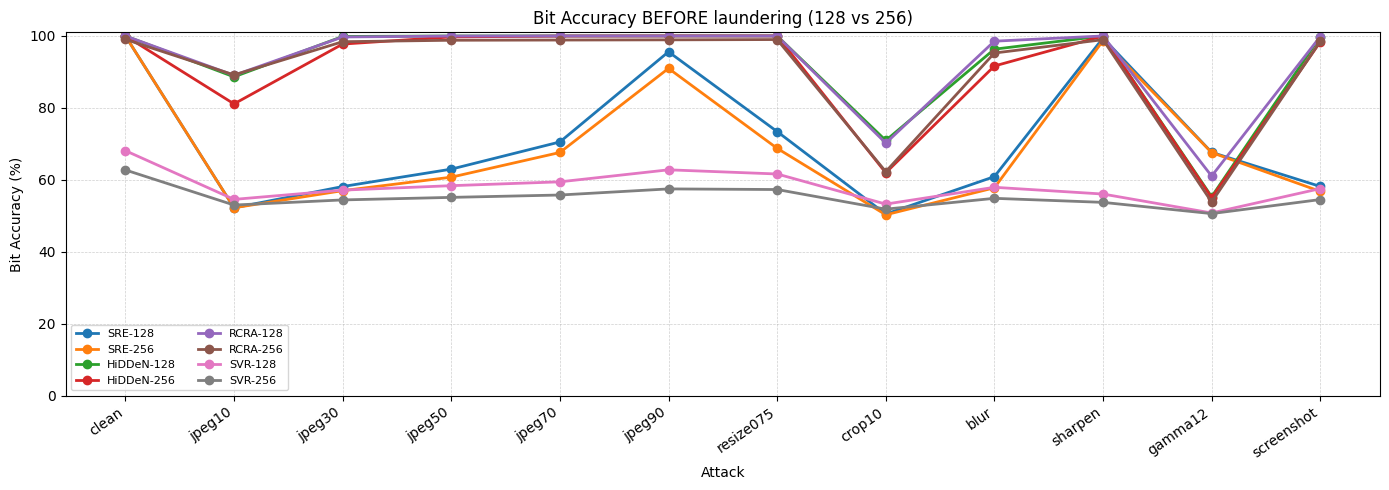

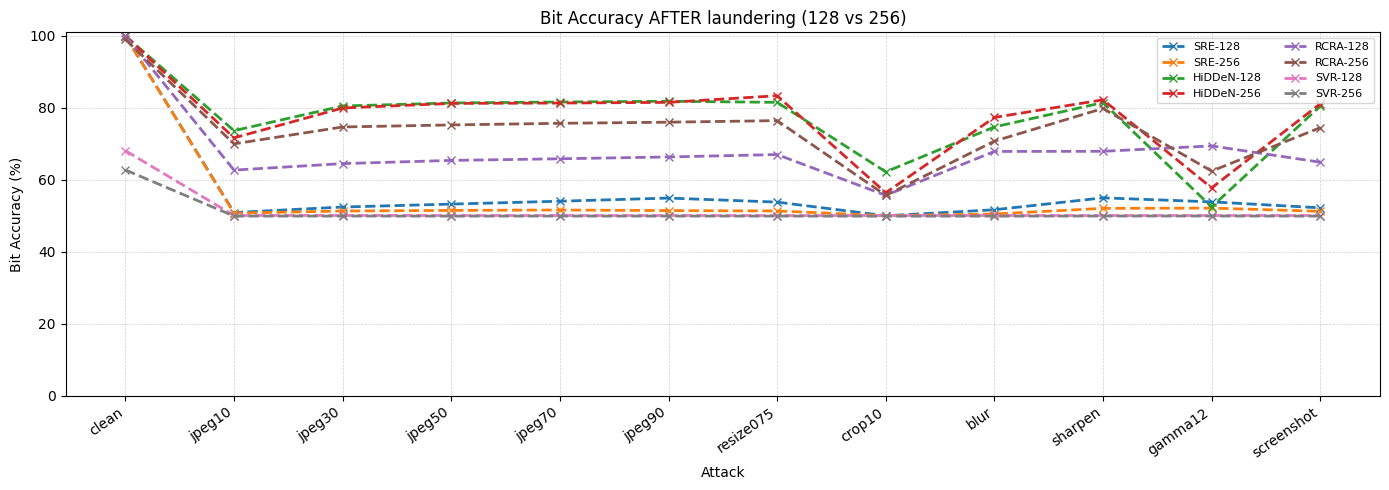

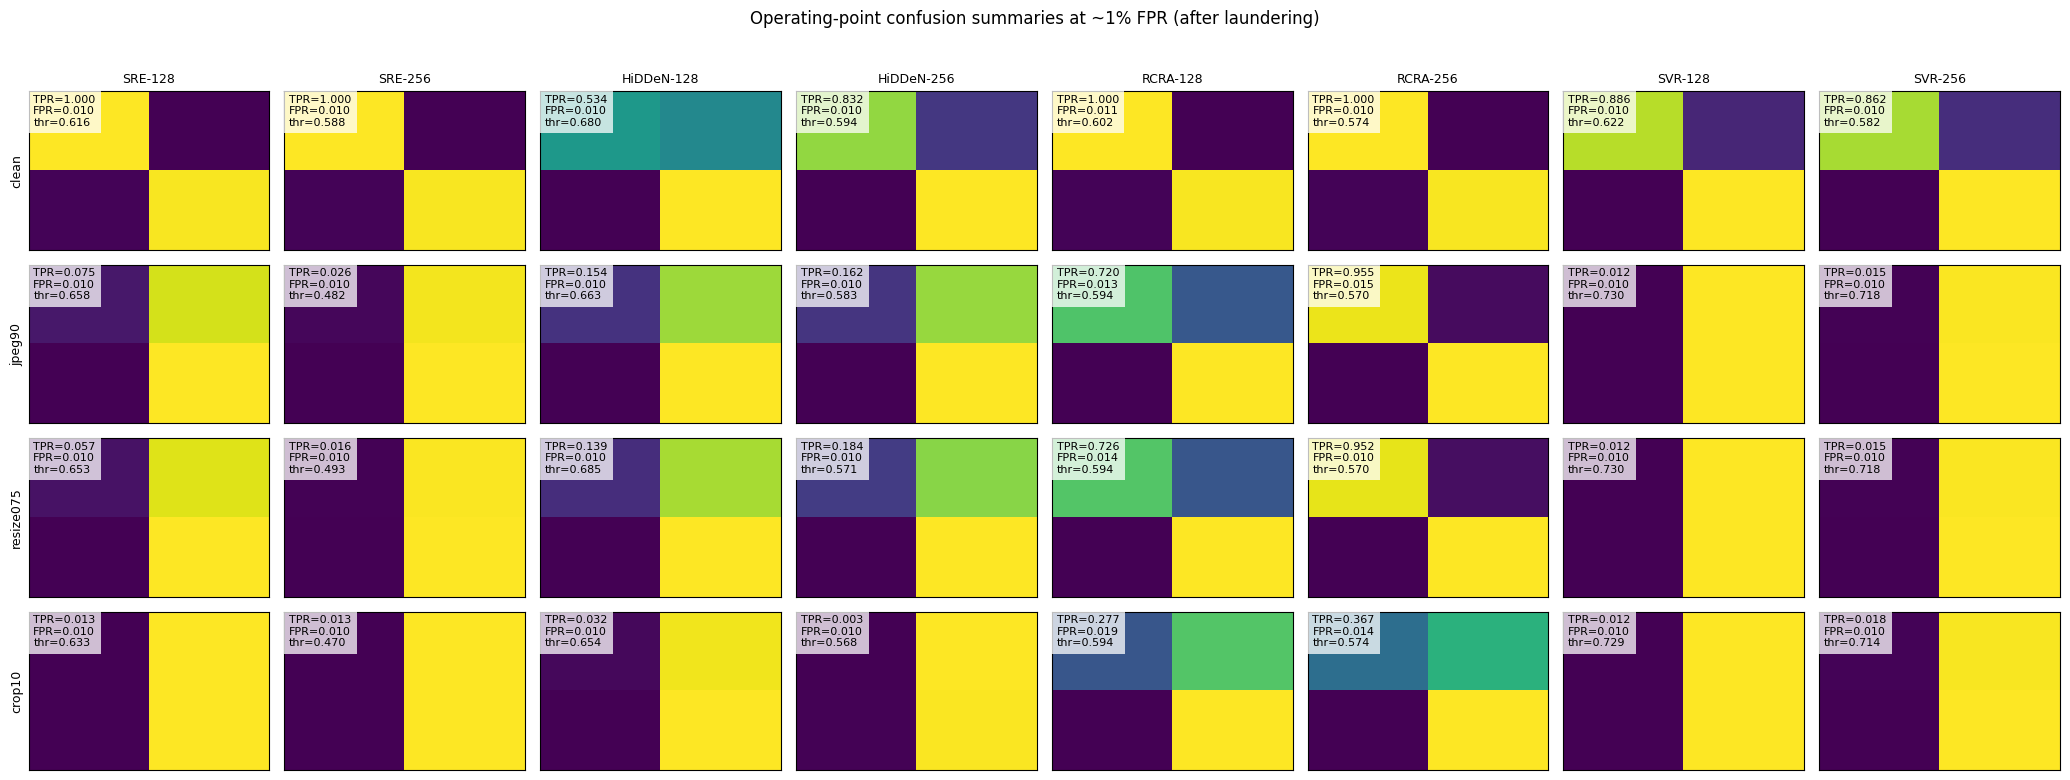

Saved figures:
 - figures/bitacc_before_128_vs_256.png
 - figures/bitacc_after_128_vs_256.png
 - figures/confusion_grid_rep_laundered.png


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Output directory
# -------------------------
os.makedirs("figures", exist_ok=True)

# Attacks shown on x-axis (same order as your paper figure)
ATTACKS = ["clean","jpeg10","jpeg30","jpeg50","jpeg70","jpeg90","resize075","crop10","blur","sharpen","gamma12","screenshot"]

# Representative attacks for confusion grid (as in your paper)
REP_ATKS = ["clean","jpeg90","resize075","crop10"]

# -------------------------
# Helpers
# -------------------------
def series_from_dict(d, attacks=ATTACKS, fill=np.nan):
    if d is None:
        return [fill for _ in attacks]
    return [float(d.get(a, fill)) for a in attacks]

def get_laundered_bitacc(r):
    for k in ["bit_acc_laundered", "mean_bit_acc_laundered"]:
        if k in r and isinstance(r[k], dict):
            return r[k]
    return None

def get_base_bitacc(r):
    for k in ["bit_acc", "mean_bit_acc"]:
        if k in r and isinstance(r[k], dict):
            return r[k]
    return None

def get_laundered_confusion_1pct(r):
    for k in [
        "conf_1pct_laundered",
        "detector_confusion_1pctfpr_by_attack_laundered",
        "presence_confusion_1pctfpr_by_attack_laundered",
        "decision_confusion_1pctfpr_by_attack_laundered",
    ]:
        if k in r and isinstance(r[k], dict):
            return r[k]
    return None

def base_family(name: str) -> str:
    # e.g., "HiDDeN-128" -> "HiDDeN"
    return name.rsplit("-", 1)[0] if "-" in name else name

# ==========================================================
# PASTE YOUR RESULTS = [...] HERE
# ==========================================================
RESULTS = [
  # =========================
  # cGAN (Detector) — 128 bits
  # =========================
  {
    "name": "SRE-128",
    "bits": 128,
    "bit_acc": {
      "clean": 100.0,
      "jpeg10": 52.2234375,
      "jpeg30": 58.14296875,
      "jpeg50": 62.97734375,
      "jpeg70": 70.5375,
      "jpeg90": 95.590625,
      "resize075": 73.421875,
      "crop10": 50.49140625,
      "blur": 60.9,
      "sharpen": 99.42578125,
      "gamma12": 67.640625,
      "screenshot": 58.16796875,
      "launder_only": 100.0,
    },
    "mean_bit_acc_laundered": {
      "clean": 100.0,
      "jpeg10": 50.91875,
      "jpeg30": 52.446875,
      "jpeg50": 53.26171875,
      "jpeg70": 54.06171875,
      "jpeg90": 54.93671875,
      "resize075": 53.81484375,
      "crop10": 50.0234375,
      "blur": 51.690625,
      "sharpen": 54.99921875,
      "gamma12": 53.88203125,
      "screenshot": 52.22421875,
      "launder_only": 55.12578125,
    },
    "detector_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.6161445170640946, "TP": 1000, "FP": 10, "TN": 990, "FN": 0, "fpr_actual": 0.01, "tpr_actual": 1.0},
      "jpeg10": {"thr": 0.6374796342849731, "TP": 19, "FP": 10, "TN": 990, "FN": 981, "fpr_actual": 0.01, "tpr_actual": 0.019},
      "jpeg30": {"thr": 0.6378311777114868, "TP": 49, "FP": 10, "TN": 990, "FN": 951, "fpr_actual": 0.01, "tpr_actual": 0.049},
      "jpeg50": {"thr": 0.6465647965669632, "TP": 46, "FP": 10, "TN": 990, "FN": 954, "fpr_actual": 0.01, "tpr_actual": 0.046},
      "jpeg70": {"thr": 0.656498372554779, "TP": 48, "FP": 10, "TN": 990, "FN": 952, "fpr_actual": 0.01, "tpr_actual": 0.048},
      "jpeg90": {"thr": 0.6576958483457565, "TP": 75, "FP": 10, "TN": 990, "FN": 925, "fpr_actual": 0.01, "tpr_actual": 0.075},
      "resize075": {"thr": 0.6534614801406861, "TP": 57, "FP": 10, "TN": 990, "FN": 943, "fpr_actual": 0.01, "tpr_actual": 0.057},
      "crop10": {"thr": 0.6326116043329238, "TP": 13, "FP": 10, "TN": 990, "FN": 987, "fpr_actual": 0.01, "tpr_actual": 0.013},
      "blur": {"thr": 0.6443998509645462, "TP": 41, "FP": 10, "TN": 990, "FN": 959, "fpr_actual": 0.01, "tpr_actual": 0.041},
      "sharpen": {"thr": 0.6620912331342698, "TP": 72, "FP": 10, "TN": 990, "FN": 928, "fpr_actual": 0.01, "tpr_actual": 0.072},
      "gamma12": {"thr": 0.6092120170593261, "TP": 62, "FP": 10, "TN": 990, "FN": 938, "fpr_actual": 0.01, "tpr_actual": 0.062},
      "screenshot": {"thr": 0.653044695854187, "TP": 22, "FP": 10, "TN": 990, "FN": 978, "fpr_actual": 0.01, "tpr_actual": 0.022},
      "launder_only": {"thr": 0.660586953163147, "TP": 88, "FP": 10, "TN": 990, "FN": 912, "fpr_actual": 0.01, "tpr_actual": 0.088},
    },
  },

  # =========================
  # cGAN (Detector) — 256 bits
  # =========================
  {
    "name": "SRE-256",
    "bits": 256,
    "bit_acc": {
      "clean": 100.0,
      "jpeg10": 52.23671875,
      "jpeg30": 56.996875,
      "jpeg50": 60.74296875,
      "jpeg70": 67.609765625,
      "jpeg90": 90.978515625,
      "resize075": 68.761328125,
      "crop10": 50.292578125,
      "blur": 57.79296875,
      "sharpen": 98.670703125,
      "gamma12": 67.591796875,
      "screenshot": 56.79453125,
      "launder_only": 100.0,
    },
    "mean_bit_acc_laundered": {
      "clean": 100.0,
      "jpeg10": 50.7453125,
      "jpeg30": 51.342578125,
      "jpeg50": 51.5125,
      "jpeg70": 51.619921875,
      "jpeg90": 51.4578125,
      "resize075": 51.35859375,
      "crop10": 50.045703125,
      "blur": 50.51484375,
      "sharpen": 52.07890625,
      "gamma12": 52.15546875,
      "screenshot": 51.25703125,
      "launder_only": 51.5203125,
    },
    "detector_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.5881248211860657, "TP": 1000, "FP": 10, "TN": 990, "FN": 0, "fpr_actual": 0.01, "tpr_actual": 1.0},
      "jpeg10": {"thr": 0.47575486451387405, "TP": 18, "FP": 10, "TN": 990, "FN": 982, "fpr_actual": 0.01, "tpr_actual": 0.018},
      "jpeg30": {"thr": 0.48259213387966154, "TP": 29, "FP": 10, "TN": 990, "FN": 971, "fpr_actual": 0.01, "tpr_actual": 0.029},
      "jpeg50": {"thr": 0.4837121647596359, "TP": 26, "FP": 10, "TN": 990, "FN": 974, "fpr_actual": 0.01, "tpr_actual": 0.026},
      "jpeg70": {"thr": 0.4806042313575744, "TP": 31, "FP": 10, "TN": 990, "FN": 969, "fpr_actual": 0.01, "tpr_actual": 0.031},
      "jpeg90": {"thr": 0.4821768534183502, "TP": 26, "FP": 10, "TN": 990, "FN": 974, "fpr_actual": 0.01, "tpr_actual": 0.026},
      "resize075": {"thr": 0.49304330587387085, "TP": 16, "FP": 10, "TN": 990, "FN": 984, "fpr_actual": 0.01, "tpr_actual": 0.016},
      "crop10": {"thr": 0.470378306210041, "TP": 13, "FP": 10, "TN": 990, "FN": 987, "fpr_actual": 0.01, "tpr_actual": 0.013},
      "blur": {"thr": 0.4975210705399513, "TP": 9, "FP": 10, "TN": 990, "FN": 991, "fpr_actual": 0.01, "tpr_actual": 0.009},
      "sharpen": {"thr": 0.4798180654644966, "TP": 62, "FP": 10, "TN": 990, "FN": 938, "fpr_actual": 0.01, "tpr_actual": 0.062},
      "gamma12": {"thr": 0.4778269299864769, "TP": 40, "FP": 10, "TN": 990, "FN": 960, "fpr_actual": 0.01, "tpr_actual": 0.04},
      "screenshot": {"thr": 0.4921057838201523, "TP": 18, "FP": 10, "TN": 990, "FN": 982, "fpr_actual": 0.01, "tpr_actual": 0.018},
      "launder_only": {"thr": 0.4946392264962196, "TP": 22, "FP": 10, "TN": 990, "FN": 978, "fpr_actual": 0.01, "tpr_actual": 0.022},
    },
  },

  # =========================
  # HiDDeN (Presence) — 128 bits
  # =========================
  {
    "name": "HiDDeN-128",
    "bits": 128,
    "bit_acc": {
      "clean": 100.0,
      "jpeg10": 88.625,
      "jpeg30": 99.84921875,
      "jpeg50": 99.98515625,
      "jpeg70": 99.99765625,
      "jpeg90": 100.0,
      "resize075": 100.0,
      "crop10": 70.9453125,
      "blur": 96.31640625,
      "sharpen": 99.99453125,
      "gamma12": 55.31015625,
      "screenshot": 99.8203125,
      "launder_only": 100.0,
    },
    "mean_bit_acc_laundered": {
      "clean": 100.0,
      "jpeg10": 73.67109375,
      "jpeg30": 80.528125,
      "jpeg50": 81.36953125,
      "jpeg70": 81.6359375,
      "jpeg90": 81.84921875,
      "resize075": 81.53828125,
      "crop10": 62.23125,
      "blur": 74.703125,
      "sharpen": 81.46953125,
      "gamma12": 52.46953125,
      "screenshot": 80.50859375,
      "launder_only": 83.0125,
    },
    "presence_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.6799125617742539, "TP": 534, "FP": 10, "TN": 990, "FN": 466, "fpr_actual": 0.01, "tpr_actual": 0.534},
      "jpeg10": {"thr": 0.6358999961614609, "TP": 75, "FP": 10, "TN": 990, "FN": 925, "fpr_actual": 0.01, "tpr_actual": 0.075},
      "jpeg30": {"thr": 0.6560604596138, "TP": 84, "FP": 10, "TN": 990, "FN": 916, "fpr_actual": 0.01, "tpr_actual": 0.084},
      "jpeg50": {"thr": 0.6587139248847961, "TP": 86, "FP": 10, "TN": 990, "FN": 914, "fpr_actual": 0.01, "tpr_actual": 0.086},
      "jpeg70": {"thr": 0.6673149698972702, "TP": 99, "FP": 10, "TN": 990, "FN": 901, "fpr_actual": 0.01, "tpr_actual": 0.099},
      "jpeg90": {"thr": 0.6633475315570831, "TP": 154, "FP": 10, "TN": 990, "FN": 846, "fpr_actual": 0.01, "tpr_actual": 0.154},
      "resize075": {"thr": 0.6852093404531479, "TP": 139, "FP": 10, "TN": 990, "FN": 861, "fpr_actual": 0.01, "tpr_actual": 0.139},
      "crop10": {"thr": 0.6539763927459716, "TP": 32, "FP": 10, "TN": 990, "FN": 968, "fpr_actual": 0.01, "tpr_actual": 0.032},
      "blur": {"thr": 0.6799125617742539, "TP": 92, "FP": 10, "TN": 990, "FN": 908, "fpr_actual": 0.01, "tpr_actual": 0.092},
      "sharpen": {"thr": 0.6799125617742539, "TP": 201, "FP": 10, "TN": 990, "FN": 799, "fpr_actual": 0.01, "tpr_actual": 0.201},
      "gamma12": {"thr": 0.6799125617742539, "TP": 114, "FP": 10, "TN": 990, "FN": 886, "fpr_actual": 0.01, "tpr_actual": 0.114},
      "screenshot": {"thr": 0.65645770072937, "TP": 80, "FP": 10, "TN": 990, "FN": 920, "fpr_actual": 0.01, "tpr_actual": 0.08},
      "launder_only": {"thr": 0.6799125617742539, "TP": 174, "FP": 10, "TN": 990, "FN": 826, "fpr_actual": 0.01, "tpr_actual": 0.174},
    },
  },

  # =========================
  # HiDDeN (Presence) — 256 bits
  # =========================
  {
    "name": "HiDDeN-256",
    "bits": 256,
    "bit_acc": {
      "clean": 99.998828125,
      "jpeg10": 81.11015625,
      "jpeg30": 97.738671875,
      "jpeg50": 99.7234375,
      "jpeg70": 99.962109375,
      "jpeg90": 99.99921875,
      "resize075": 100.0,
      "crop10": 61.962109375,
      "blur": 91.64296875,
      "sharpen": 99.9734375,
      "gamma12": 55.057421875,
      "screenshot": 98.344921875,
      "launder_only": 99.998828125,
    },
    "mean_bit_acc_laundered": {
      "clean": 99.998828125,
      "jpeg10": 71.66875,
      "jpeg30": 79.9765625,
      "jpeg50": 81.24296875,
      "jpeg70": 81.34375,
      "jpeg90": 81.537109375,
      "resize075": 83.37578125,
      "crop10": 56.422265625,
      "blur": 77.3484375,
      "sharpen": 82.240625,
      "gamma12": 57.770703125,
      "screenshot": 81.145703125,
      "launder_only": 79.683984375,
    },
    "presence_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.5942571341991425, "TP": 832, "FP": 10, "TN": 990, "FN": 168, "fpr_actual": 0.01, "tpr_actual": 0.832},
      "jpeg10": {"thr": 0.6124868071079254, "TP": 3, "FP": 10, "TN": 990, "FN": 997, "fpr_actual": 0.01, "tpr_actual": 0.003},
      "jpeg30": {"thr": 0.5933936047554016, "TP": 9, "FP": 10, "TN": 990, "FN": 991, "fpr_actual": 0.01, "tpr_actual": 0.009},
      "jpeg50": {"thr": 0.5740520513057709, "TP": 67, "FP": 10, "TN": 990, "FN": 933, "fpr_actual": 0.01, "tpr_actual": 0.067},
      "jpeg70": {"thr": 0.5812053620815276, "TP": 101, "FP": 10, "TN": 990, "FN": 899, "fpr_actual": 0.01, "tpr_actual": 0.101},
      "jpeg90": {"thr": 0.5831363087892532, "TP": 162, "FP": 10, "TN": 990, "FN": 838, "fpr_actual": 0.01, "tpr_actual": 0.162},
      "resize075": {"thr": 0.5711280745267868, "TP": 184, "FP": 10, "TN": 990, "FN": 816, "fpr_actual": 0.01, "tpr_actual": 0.184},
      "crop10": {"thr": 0.5681614905595779, "TP": 3, "FP": 10, "TN": 990, "FN": 997, "fpr_actual": 0.01, "tpr_actual": 0.003},
      "blur": {"thr": 0.5942571341991425, "TP": 5, "FP": 10, "TN": 990, "FN": 995, "fpr_actual": 0.01, "tpr_actual": 0.005},
      "sharpen": {"thr": 0.5942571341991425, "TP": 322, "FP": 10, "TN": 990, "FN": 678, "fpr_actual": 0.01, "tpr_actual": 0.322},
      "gamma12": {"thr": 0.5942571341991425, "TP": 232, "FP": 10, "TN": 990, "FN": 768, "fpr_actual": 0.01, "tpr_actual": 0.232},
      "screenshot": {"thr": 0.571911779642105, "TP": 13, "FP": 10, "TN": 990, "FN": 987, "fpr_actual": 0.01, "tpr_actual": 0.013},
      "launder_only": {"thr": 0.5942571341991425, "TP": 210, "FP": 10, "TN": 990, "FN": 790, "fpr_actual": 0.01, "tpr_actual": 0.21},
    },
  },

  # =========================
  # FLEXMark-RL (Decision) — 128 bits
  # =========================
  {
    "name": "RCRA-128",
    "bits": 128,
    "bit_acc": {
      "clean": 99.99921875,
      "jpeg10": 89.059375,
      "jpeg30": 99.709375,
      "jpeg50": 99.9640625,
      "jpeg70": 99.99296875,
      "jpeg90": 99.9984375,
      "resize075": 100.0,
      "crop10": 70.20859375,
      "blur": 98.5421875,
      "sharpen": 99.98984375,
      "gamma12": 61.0484375,
      "screenshot": 99.82734375,
      "launder_only": 99.99921875,
    },
    "mean_bit_acc_laundered": {
      "clean": 99.99921875,
      "jpeg10": 62.7125,
      "jpeg30": 64.51640625,
      "jpeg50": 65.40234375,
      "jpeg70": 65.859375,
      "jpeg90": 66.3609375,
      "resize075": 67.03515625,
      "crop10": 55.69296875,
      "blur": 67.89609375,
      "sharpen": 67.93515625,
      "gamma12": 69.43515625,
      "screenshot": 64.9078125,
      "launder_only": 66.70390625,
    },
    "decision_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.6015625, "TP": 1000, "FP": 11, "TN": 989, "FN": 0, "fpr_actual": 0.011, "tpr_actual": 1.0},
      "jpeg10": {"thr": 0.59375, "TP": 676, "FP": 11, "TN": 989, "FN": 324, "fpr_actual": 0.011, "tpr_actual": 0.676},
      "jpeg30": {"thr": 0.59375, "TP": 686, "FP": 13, "TN": 987, "FN": 314, "fpr_actual": 0.013, "tpr_actual": 0.686},
      "jpeg50": {"thr": 0.59375, "TP": 704, "FP": 12, "TN": 988, "FN": 296, "fpr_actual": 0.012, "tpr_actual": 0.704},
      "jpeg70": {"thr": 0.59375, "TP": 712, "FP": 15, "TN": 985, "FN": 288, "fpr_actual": 0.015, "tpr_actual": 0.712},
      "jpeg90": {"thr": 0.59375, "TP": 720, "FP": 13, "TN": 987, "FN": 280, "fpr_actual": 0.013, "tpr_actual": 0.72},
      "resize075": {"thr": 0.59375, "TP": 726, "FP": 14, "TN": 986, "FN": 274, "fpr_actual": 0.014, "tpr_actual": 0.726},
      "crop10": {"thr": 0.59375, "TP": 277, "FP": 19, "TN": 981, "FN": 723, "fpr_actual": 0.019, "tpr_actual": 0.277},
      "blur": {"thr": 0.6015625, "TP": 780, "FP": 12, "TN": 988, "FN": 220, "fpr_actual": 0.012, "tpr_actual": 0.78},
      "sharpen": {"thr": 0.59375, "TP": 766, "FP": 13, "TN": 987, "FN": 234, "fpr_actual": 0.013, "tpr_actual": 0.766},
      "gamma12": {"thr": 0.6016406249999999, "TP": 804, "FP": 10, "TN": 990, "FN": 196, "fpr_actual": 0.01, "tpr_actual": 0.804},
      "screenshot": {"thr": 0.59375, "TP": 696, "FP": 17, "TN": 983, "FN": 304, "fpr_actual": 0.017, "tpr_actual": 0.696},
      "launder_only": {"thr": 0.5859375, "TP": 746, "FP": 22, "TN": 978, "FN": 254, "fpr_actual": 0.022, "tpr_actual": 0.746},
    },
  },

  # =========================
  # FLEXMark-RL (Decision) — 256 bits
  # =========================
  {
    "name": "RCRA-256",
    "bits": 256,
    "bit_acc": {
      "clean": 99.028515625,
      "jpeg10": 89.165625,
      "jpeg30": 98.396484375,
      "jpeg50": 98.799609375,
      "jpeg70": 98.85859375,
      "jpeg90": 98.9140625,
      "resize075": 98.992578125,
      "crop10": 62.276171875,
      "blur": 95.251953125,
      "sharpen": 98.956640625,
      "gamma12": 53.823046875,
      "screenshot": 98.491796875,
      "launder_only": 99.028515625,
    },
    "mean_bit_acc_laundered": {
      "clean": 99.028515625,
      "jpeg10": 70.005078125,
      "jpeg30": 74.696484375,
      "jpeg50": 75.265625,
      "jpeg70": 75.71640625,
      "jpeg90": 76.025390625,
      "resize075": 76.461328125,
      "crop10": 55.693359375,
      "blur": 70.760546875,
      "sharpen": 79.848046875,
      "gamma12": 62.437890625,
      "screenshot": 74.50625,
      "launder_only": 71.558984375,
    },
    "decision_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.5742578125, "TP": 1000, "FP": 10, "TN": 990, "FN": 0, "fpr_actual": 0.01, "tpr_actual": 1.0},
      "jpeg10": {"thr": 0.5703125, "TP": 956, "FP": 13, "TN": 987, "FN": 44, "fpr_actual": 0.013, "tpr_actual": 0.956},
      "jpeg30": {"thr": 0.5703125, "TP": 959, "FP": 14, "TN": 986, "FN": 41, "fpr_actual": 0.014, "tpr_actual": 0.959},
      "jpeg50": {"thr": 0.5703515625, "TP": 953, "FP": 10, "TN": 990, "FN": 47, "fpr_actual": 0.01, "tpr_actual": 0.953},
      "jpeg70": {"thr": 0.5703125, "TP": 955, "FP": 14, "TN": 986, "FN": 45, "fpr_actual": 0.014, "tpr_actual": 0.955},
      "jpeg90": {"thr": 0.5703125, "TP": 955, "FP": 15, "TN": 985, "FN": 45, "fpr_actual": 0.015, "tpr_actual": 0.955},
      "resize075": {"thr": 0.5703515625, "TP": 952, "FP": 10, "TN": 990, "FN": 48, "fpr_actual": 0.01, "tpr_actual": 0.952},
      "crop10": {"thr": 0.57421875, "TP": 367, "FP": 14, "TN": 986, "FN": 633, "fpr_actual": 0.014, "tpr_actual": 0.367},
      "blur": {"thr": 0.5742578125, "TP": 920, "FP": 10, "TN": 990, "FN": 80, "fpr_actual": 0.01, "tpr_actual": 0.92},
      "sharpen": {"thr": 0.57421875, "TP": 971, "FP": 13, "TN": 987, "FN": 29, "fpr_actual": 0.013, "tpr_actual": 0.971},
      "gamma12": {"thr": 0.5742578125, "TP": 680, "FP": 10, "TN": 990, "FN": 320, "fpr_actual": 0.01, "tpr_actual": 0.68},
      "screenshot": {"thr": 0.57421875, "TP": 949, "FP": 12, "TN": 988, "FN": 51, "fpr_actual": 0.012, "tpr_actual": 0.949},
      "launder_only": {"thr": 0.5703125, "TP": 925, "FP": 11, "TN": 989, "FN": 75, "fpr_actual": 0.011, "tpr_actual": 0.925},
    },
  },

  # =========================
  # LinearSVR (Detector) — 128 bits
  # =========================
  {
    "name": "SVR-128",
    "bits": 128,
    "bit_acc": {
      "clean": 68.11015625,
      "jpeg10": 54.56953125,
      "jpeg30": 57.1421875,
      "jpeg50": 58.38046875,
      "jpeg70": 59.45078125,
      "jpeg90": 62.78828125,
      "resize075": 61.63203125,
      "crop10": 53.26015625,
      "blur": 57.93203125,
      "sharpen": 56.05703125,
      "gamma12": 50.7953125,
      "screenshot": 57.56328125,
    },
    "mean_bit_acc_laundered": {
      "clean": 68.11015625,
      "jpeg10": 50.08828125,
      "jpeg30": 50.10078125,
      "jpeg50": 50.08984375,
      "jpeg70": 50.07734375,
      "jpeg90": 50.0859375,
      "resize075": 50.071875,
      "crop10": 50.0875,
      "blur": 50.09296875,
      "sharpen": 50.075,
      "gamma12": 50.0921875,
      "screenshot": 50.08828125,
    },
    "detector_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.6216221887782933, "TP": 886, "FP": 10, "TN": 990, "FN": 114, "fpr_actual": 0.01, "tpr_actual": 0.886},
      "jpeg10": {"thr": 0.7304140072140929, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "jpeg30": {"thr": 0.7304016074827886, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "jpeg50": {"thr": 0.7303734656335888, "TP": 11, "FP": 10, "TN": 990, "FN": 989, "fpr_actual": 0.01, "tpr_actual": 0.011},
      "jpeg70": {"thr": 0.7303734656335888, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "jpeg90": {"thr": 0.7304140072140929, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "resize075": {"thr": 0.7304140072140929, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "crop10": {"thr": 0.7285485551774653, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "blur": {"thr": 0.7304140072140929, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "sharpen": {"thr": 0.7304159422629435, "TP": 11, "FP": 10, "TN": 990, "FN": 989, "fpr_actual": 0.01, "tpr_actual": 0.011},
      "gamma12": {"thr": 0.7303874170392978, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
      "screenshot": {"thr": 0.7303734656335888, "TP": 12, "FP": 10, "TN": 990, "FN": 988, "fpr_actual": 0.01, "tpr_actual": 0.012},
    },
  },

  # =========================
  # LinearSVR (Detector) — 256 bits
  # =========================
  {
    "name": "SVR-256",
    "bits": 256,
    "bit_acc": {
      "clean": 62.75,
      "jpeg10": 52.994921875,
      "jpeg30": 54.422265625,
      "jpeg50": 55.129296875,
      "jpeg70": 55.785546875,
      "jpeg90": 57.48359375,
      "resize075": 57.31171875,
      "crop10": 51.85546875,
      "blur": 54.8671875,
      "sharpen": 53.744140625,
      "gamma12": 50.61953125,
      "screenshot": 54.5265625,
    },
    "mean_bit_acc_laundered": {
      "clean": 62.75,
      "jpeg10": 49.926953125,
      "jpeg30": 49.938671875,
      "jpeg50": 49.928515625,
      "jpeg70": 49.93671875,
      "jpeg90": 49.93359375,
      "resize075": 49.933984375,
      "crop10": 49.90546875,
      "blur": 49.917578125,
      "sharpen": 49.94921875,
      "gamma12": 49.951953125,
      "screenshot": 49.926953125,
    },
    "detector_confusion_1pctfpr_by_attack_laundered": {
      "clean": {"thr": 0.5822404619753109, "TP": 862, "FP": 10, "TN": 990, "FN": 138, "fpr_actual": 0.01, "tpr_actual": 0.862},
      "jpeg10": {"thr": 0.7181434347374361, "TP": 16, "FP": 10, "TN": 990, "FN": 984, "fpr_actual": 0.01, "tpr_actual": 0.016},
      "jpeg30": {"thr": 0.7181434347374361, "TP": 15, "FP": 10, "TN": 990, "FN": 985, "fpr_actual": 0.01, "tpr_actual": 0.015},
      "jpeg50": {"thr": 0.7177227804432977, "TP": 15, "FP": 10, "TN": 990, "FN": 985, "fpr_actual": 0.01, "tpr_actual": 0.015},
      "jpeg70": {"thr": 0.7177227804432977, "TP": 16, "FP": 10, "TN": 990, "FN": 984, "fpr_actual": 0.01, "tpr_actual": 0.016},
      "jpeg90": {"thr": 0.7181434347374361, "TP": 15, "FP": 10, "TN": 990, "FN": 985, "fpr_actual": 0.01, "tpr_actual": 0.015},
      "resize075": {"thr": 0.7177227804432977, "TP": 15, "FP": 10, "TN": 990, "FN": 985, "fpr_actual": 0.01, "tpr_actual": 0.015},
      "crop10": {"thr": 0.7141967141608049, "TP": 18, "FP": 10, "TN": 990, "FN": 982, "fpr_actual": 0.01, "tpr_actual": 0.018},
      "blur": {"thr": 0.7166329490208451, "TP": 17, "FP": 10, "TN": 990, "FN": 983, "fpr_actual": 0.01, "tpr_actual": 0.017},
      "sharpen": {"thr": 0.7181434347374361, "TP": 15, "FP": 10, "TN": 990, "FN": 985, "fpr_actual": 0.01, "tpr_actual": 0.015},
      "gamma12": {"thr": 0.7166208367559177, "TP": 16, "FP": 10, "TN": 990, "FN": 984, "fpr_actual": 0.01, "tpr_actual": 0.016},
      "screenshot": {"thr": 0.7181434347374361, "TP": 15, "FP": 10, "TN": 990, "FN": 985, "fpr_actual": 0.01, "tpr_actual": 0.015},
    },
  },
]

# -------------------------
# Sanity check (prevents silent blank plots)
# -------------------------
assert "RESULTS" in globals() and isinstance(RESULTS, list) and len(RESULTS) > 0, \
    "RESULTS is empty or not defined. Make sure you pasted RESULTS = [...] above and did NOT reset it."

print("Models:", [r["name"] for r in RESULTS])

# -------------------------
# Group models into 128/256 families (e.g., HiDDeN-128, HiDDeN-256)
# -------------------------
families = {}
for r in RESULTS:
    fam = base_family(r["name"])
    families.setdefault(fam, []).append(r)

# stable ordering: 128 then 256
for fam in families:
    families[fam] = sorted(families[fam], key=lambda z: int(z.get("bits", 0)))

# -------------------------
# Figure 1A: BitAcc BEFORE laundering — 128 and 256 together
# -------------------------
x = np.arange(len(ATTACKS))

plt.figure(figsize=(14, 5))
for fam, rs in families.items():
    for r in rs:
        base = get_base_bitacc(r)
        y = series_from_dict(base, ATTACKS)
        plt.plot(
            x, y,
            marker="o",
            linewidth=2,
            label=f"{fam}-{r['bits']}"
        )

plt.xticks(x, ATTACKS, rotation=35, ha="right")
plt.ylim(0, 101)
plt.xlabel("Attack")
plt.ylabel("Bit Accuracy (%)")
plt.title("Bit Accuracy BEFORE laundering (128 vs 256)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend(ncol=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig("figures/bitacc_before_128_vs_256.png", dpi=200)
plt.show()

# -------------------------
# Figure 1B: BitAcc AFTER laundering — 128 and 256 together
# -------------------------
plt.figure(figsize=(14, 5))
for fam, rs in families.items():
    for r in rs:
        laun = get_laundered_bitacc(r)
        y = series_from_dict(laun, ATTACKS)
        plt.plot(
            x, y,
            marker="x",
            linewidth=2,
            linestyle="--",
            label=f"{fam}-{r['bits']}"
        )

plt.xticks(x, ATTACKS, rotation=35, ha="right")
plt.ylim(0, 101)
plt.xlabel("Attack")
plt.ylabel("Bit Accuracy (%)")
plt.title("Bit Accuracy AFTER laundering (128 vs 256)")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
plt.legend(ncol=2, fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig("figures/bitacc_after_128_vs_256.png", dpi=200)
plt.show()

# -------------------------
# Figure 2: Confusion grid (laundered) @ ~1% FPR
# -------------------------
N = len(RESULTS)
R = len(REP_ATKS)

fig = plt.figure(figsize=(2.6 * N, 1.9 * R))

for i, atk in enumerate(REP_ATKS):
    for j, r in enumerate(RESULTS):
        ax = plt.subplot(R, N, i * N + j + 1)

        confL = get_laundered_confusion_1pct(r)
        c = confL.get(atk) if isinstance(confL, dict) else None

        ax.set_xticks([])
        ax.set_yticks([])

        if i == 0:
            ax.set_title(r["name"], fontsize=9)
        if j == 0:
            ax.set_ylabel(atk, fontsize=9)

        if not c:
            ax.imshow(np.zeros((2, 2)), aspect="auto")
            ax.text(0.5, 0.5, "NA", transform=ax.transAxes,
                    ha="center", va="center", fontsize=10,
                    bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
            continue

        mat = np.array([[c["TP"], c["FN"]],
                        [c["FP"], c["TN"]]], dtype=float)

        ax.imshow(mat, aspect="auto")

        tpr = float(c.get("tpr_actual", np.nan))
        fpr = float(c.get("fpr_actual", np.nan))
        thr = float(c.get("thr", np.nan))

        ax.text(0.02, 0.98,
                f"TPR={tpr:.3f}\nFPR={fpr:.3f}\nthr={thr:.3f}",
                transform=ax.transAxes, va="top", ha="left",
                fontsize=8,
                bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

plt.suptitle("Operating-point confusion summaries at ~1% FPR (after laundering)", y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig("figures/confusion_grid_rep_laundered.png", dpi=200, bbox_inches="tight")
plt.show()

print("Saved figures:")
print(" - figures/bitacc_before_128_vs_256.png")
print(" - figures/bitacc_after_128_vs_256.png")
print(" - figures/confusion_grid_rep_laundered.png")

All models: ['SRE-128', 'SRE-256', 'HiDDeN-128', 'HiDDeN-256', 'RCRA-128', 'RCRA-256', 'SVR-128', 'SVR-256']
128-bit models: ['SRE-128', 'HiDDeN-128', 'RCRA-128', 'SVR-128']
256-bit models: ['SRE-256', 'HiDDeN-256', 'RCRA-256', 'SVR-256']


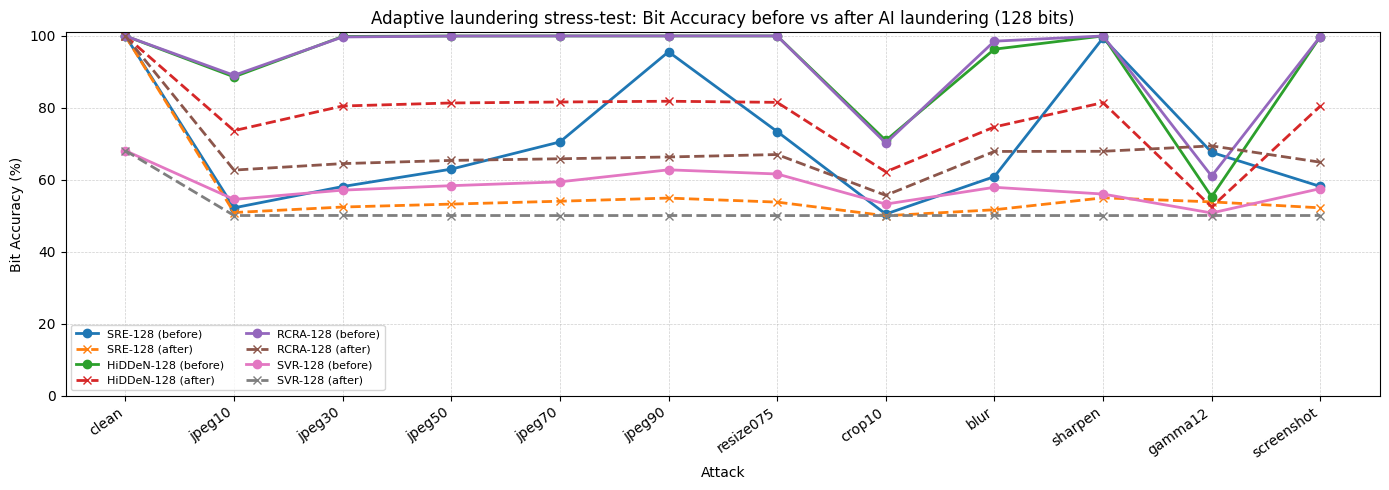

Saved: figures/bitacc_laundering_before_after_128.png


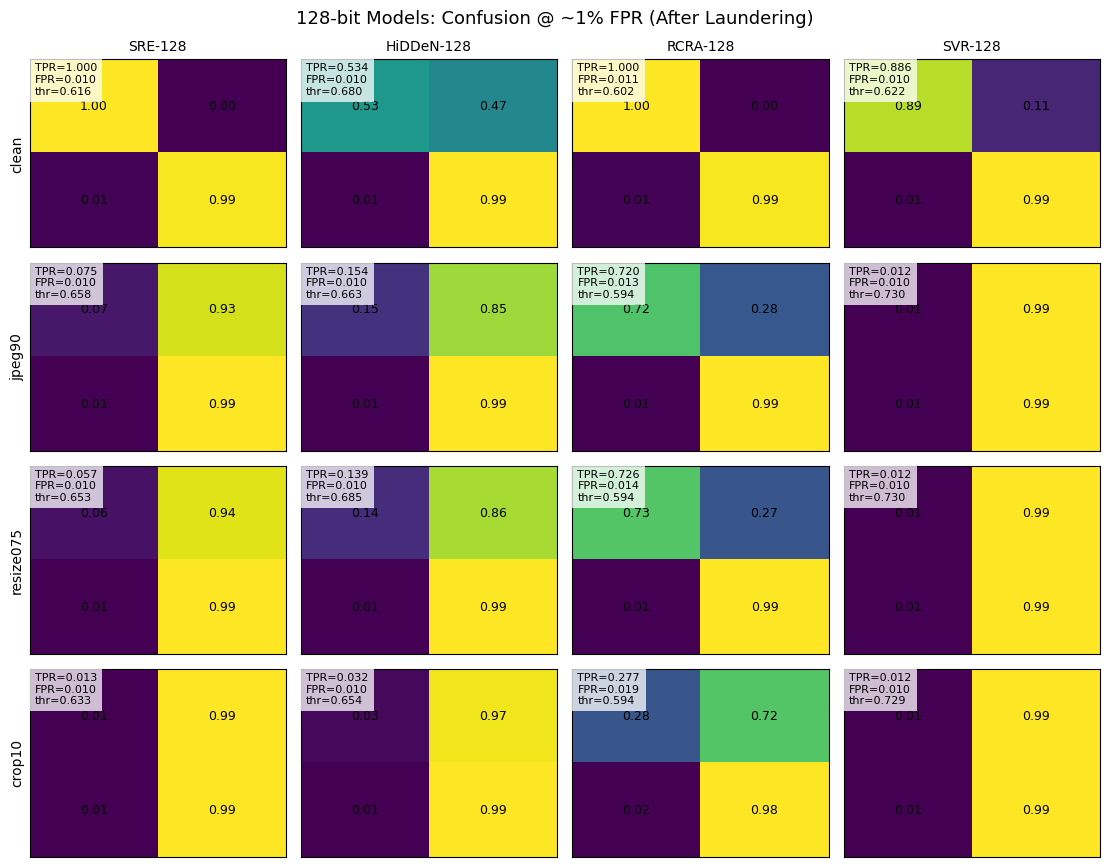

Saved: figures/confusion_128_best4.png


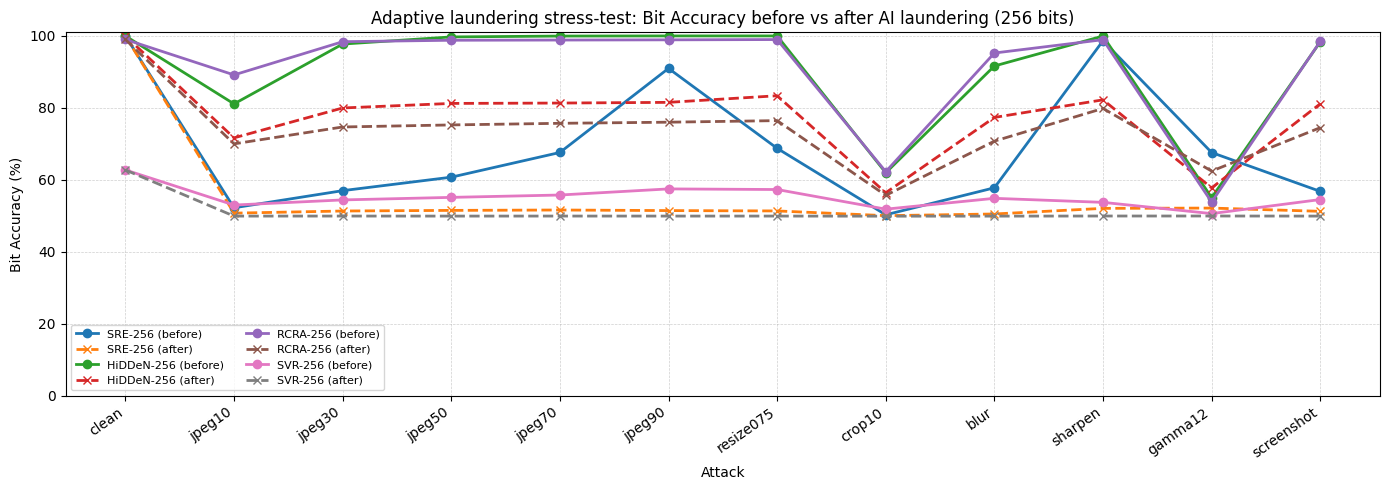

Saved: figures/bitacc_laundering_before_after_256.png


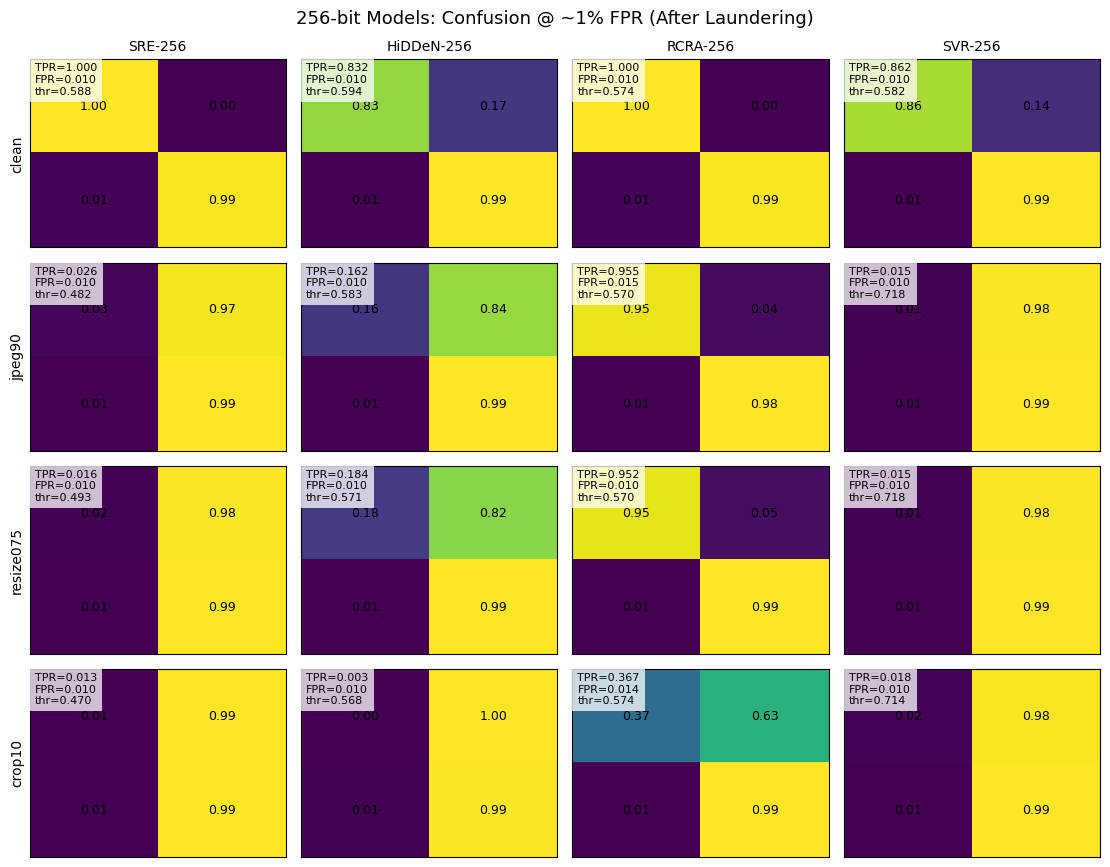

Saved: figures/confusion_256_best4.png
Done. Check the figures/ folder for PNGs.


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

ATTACKS = ["clean","jpeg10","jpeg30","jpeg50","jpeg70","jpeg90","resize075","crop10","blur","sharpen","gamma12","screenshot"]
REP_ATKS = ["clean","jpeg90","resize075","crop10"]  # your chosen representative set

def series_from_dict(d, attacks=ATTACKS, fill=np.nan):
    if d is None:
        return [fill for _ in attacks]
    return [float(d.get(a, fill)) for a in attacks]

def get_laundered_bitacc(r):
    for k in ["bit_acc_laundered", "mean_bit_acc_laundered"]:
        if k in r and isinstance(r[k], dict):
            return r[k]
    return None

def get_base_bitacc(r):
    for k in ["bit_acc", "mean_bit_acc"]:
        if k in r and isinstance(r[k], dict):
            return r[k]
    return None

def get_laundered_confusion_1pct(r):
    for k in [
        "conf_1pct_laundered",
        "detector_confusion_1pctfpr_by_attack_laundered",
        "presence_confusion_1pctfpr_by_attack_laundered",
        "decision_confusion_1pctfpr_by_attack_laundered",
    ]:
        if k in r and isinstance(r[k], dict):
            return r[k]
    return None

# -------------------------
# Sanity check
# -------------------------
assert isinstance(RESULTS, list) and len(RESULTS) > 0, "RESULTS is empty or not defined."
print("All models:", [r.get("name","?") for r in RESULTS])

# -------------------------
# Split by payload bits
# -------------------------
RESULTS_128 = [r for r in RESULTS if int(r.get("bits", -1)) == 128]
RESULTS_256 = [r for r in RESULTS if int(r.get("bits", -1)) == 256]

print("128-bit models:", [r["name"] for r in RESULTS_128])
print("256-bit models:", [r["name"] for r in RESULTS_256])

def plot_bitacc_before_after(results_subset, bits_tag):
    """Figure: BitAcc before vs after laundering (subset)"""
    assert len(results_subset) > 0, f"No models found for bits={bits_tag}"

    x = np.arange(len(ATTACKS))
    plt.figure(figsize=(14, 5))

    for r in results_subset:
        base = get_base_bitacc(r)
        laun = get_laundered_bitacc(r)

        y_base = series_from_dict(base, ATTACKS)
        y_laun = series_from_dict(laun, ATTACKS)

        plt.plot(x, y_base, marker="o", linewidth=2, label=f'{r["name"]} (before)')
        plt.plot(x, y_laun, marker="x", linewidth=2, linestyle="--", label=f'{r["name"]} (after)')

    plt.xticks(x, ATTACKS, rotation=35, ha="right")
    plt.ylim(0, 101)
    plt.xlabel("Attack")
    plt.ylabel("Bit Accuracy (%)")
    plt.title(f"Adaptive laundering stress-test: Bit Accuracy before vs after AI laundering ({bits_tag} bits)")
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.6)
    plt.legend(ncol=2, fontsize=8, frameon=True)
    plt.tight_layout()

    out = f"figures/bitacc_laundering_before_after_{bits_tag}.png"
    plt.savefig(out, dpi=200)
    plt.show()
    plt.close()
    print("Saved:", out)

def plot_confusion_grid(results_subset, bits_tag, attacks=REP_ATKS, normalize=True):
    """
    Confusion grid (laundered) @ ~1% FPR.
    attacks: list of attacks to display
    normalize: if True, show rates in each cell (0..1) instead of counts
    """
    assert len(results_subset) > 0, f"No models found for bits={bits_tag}"

    N = len(results_subset)
    R = len(attacks)

    fig = plt.figure(figsize=(2.8 * N, 2.2 * R))

    for i, atk in enumerate(attacks):
        for j, r in enumerate(results_subset):
            ax = plt.subplot(R, N, i * N + j + 1)

            confL = get_laundered_confusion_1pct(r)
            c = confL.get(atk) if isinstance(confL, dict) else None

            ax.set_xticks([])
            ax.set_yticks([])

            if i == 0:
                ax.set_title(r["name"], fontsize=10)
            if j == 0:
                ax.set_ylabel(atk, fontsize=10)

            if not c:
                ax.imshow(np.zeros((2, 2)), aspect="auto")
                ax.text(0.5, 0.5, "NA",
                        transform=ax.transAxes,
                        ha="center", va="center",
                        fontsize=11,
                        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))
                continue

            # matrix: [[TP, FN],
            #          [FP, TN]]
            mat = np.array([[c["TP"], c["FN"]],
                            [c["FP"], c["TN"]]], dtype=float)

            if normalize:
                denom_pos = mat[0,0] + mat[0,1]  # TP+FN
                denom_neg = mat[1,0] + mat[1,1]  # FP+TN
                mat_show = mat.copy()
                if denom_pos > 0:
                    mat_show[0, :] = mat_show[0, :] / denom_pos
                if denom_neg > 0:
                    mat_show[1, :] = mat_show[1, :] / denom_neg
            else:
                mat_show = mat

            ax.imshow(mat_show, aspect="auto")

            # annotate cells
            for row in range(2):
                for col in range(2):
                    v = mat_show[row, col]
                    txt = f"{v:.2f}" if normalize else f"{int(v)}"
                    ax.text(col, row, txt, ha="center", va="center", fontsize=9)

            tpr = float(c.get("tpr_actual", np.nan))
            fpr = float(c.get("fpr_actual", np.nan))
            thr = float(c.get("thr", np.nan))

            ax.text(0.02, 0.98,
                    f"TPR={tpr:.3f}\nFPR={fpr:.3f}\nthr={thr:.3f}",
                    transform=ax.transAxes,
                    va="top", ha="left",
                    fontsize=8,
                    bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))

    plt.suptitle(f"{bits_tag}-bit Models: Confusion @ ~1% FPR (After Laundering)", fontsize=13)
    plt.tight_layout()

    out = f"figures/confusion_{bits_tag}_best4.png" if attacks == REP_ATKS else f"figures/confusion_{bits_tag}.png"
    plt.savefig(out, dpi=250, bbox_inches="tight")
    plt.show()
    plt.close()
    print("Saved:", out)

# -------------------------
# Generate 128-bit figures
# -------------------------
plot_bitacc_before_after(RESULTS_128, "128")
plot_confusion_grid(RESULTS_128, "128", attacks=REP_ATKS, normalize=True)

# -------------------------
# Generate 256-bit figures
# -------------------------
plot_bitacc_before_after(RESULTS_256, "256")
plot_confusion_grid(RESULTS_256, "256", attacks=REP_ATKS, normalize=True)

print("Done. Check the figures/ folder for PNGs.")